In [1]:
import numpy as np
import pandas as pd

## Panel 16

In [3]:
# 1) Path to MEPS Panel 16 longitudinal file (h156)
file_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h156dat\h156.dat"

# 2) Fixed-width column specifications (0-based, end-exclusive)
# Only Year 1 predictors + Year 2 outcome included
colspecs = [

    # --- Identifiers ---
    (0, 5),        # DUID        = Dwelling Unit ID
    (5, 8),        # PID         = Person Number within household
    (8, 16),       # DUPERSID    = Unique Person ID (DUID + PID)
    (16, 18),      # PANEL       = MEPS Panel Number
    (18, 19),      # YEARIND     = Year Indicator

    # --- Demographics (Predisposing Factors) ---
    (360, 362),    # AGE1X       = Age in Year 1
    (384, 385),    # SEX         = Sex
    (387, 389),    # RACEV1X     = Race
    (398, 399),    # HISPANX     = Hispanic Ethnicity
    (128, 130),    # REGION1     = Census Region (Year 1)

    # --- Socioeconomic / Enabling Factors ---
    (3145, 3147),  # POVCATY1    = Poverty Category (Year 1)
    (456, 458),    # EDRECODE    = Education Level
    (4587, 4589),  # INSCOVY1    = Insurance Coverage (Year 1)
    (2622, 2624),  # EMPST1      = Employment Status (Round 1)
    (1675, 1677),  # ADSMOK2     = Currently Smokes (Round 2)

    # --- Self-Perceived Health (Need Factors) ---
    (536, 538),    # RTHLTH1     = Perceived Physical Health Status (Round 1)
    (546, 548),    # MNHLTH1     = Perceived Mental Health Status (Round 1)

    # --- Chronic Conditions (Year 1 Diagnoses) ---
    (556, 558),    # HIBPDXY1    = Diagnosed High Blood Pressure (Year 1)
    (898, 900),    # DIABDXY1    = Diagnosed Diabetes (Year 1)
    (912, 914),    # ARTHDXY1    = Diagnosed Arthritis (Year 1)
    (906, 908),    # JTPAIN1     = Joint Pain in Last 12 Months (Round 1)
    (924, 926),    # ASTHDXY1    = Diagnosed Asthma (Year 1)
    (932, 934),    # ASSTIL1     = Still Has Asthma (Round 1)
    (938, 940),    # ASATAK1     = Asthma Attack in Last 12 Months (Round 1)
    (568, 570),    # CHDDXY1     = Coronary Heart Disease Diagnosis (Year 1)
    (584, 586),    # MIDXY1      = Heart Attack (MI) Diagnosis (Year 1)
    (600, 602),    # STRKDXY1    = Stroke Diagnosis (Year 1)
    (608, 610),    # EMPHDXY1    = Emphysema Diagnosis (Year 1)
    (622, 624),    # CHOLDXY1    = High Cholesterol Diagnosis (Year 1)

    # --- Utilization Variables ---
    (5565, 5568),  # OBTOTVY1    = Total Office-Based Provider Visits (Year 1)
    (5568, 5571),  # OBTOTVY2    = Total Office-Based Provider Visits (Year 2) ← TARGET
    (5730, 5732),  # OBDRVY1     = OFFICE-BASED PHYSICIAN VISITS 11
    (6173, 6175),  # OBNURSY1    = OFF-BASED NURSE/PRACTITIONER VISITS 11
    (6312, 6313),  # OBOPTOY1    = OFF-BASED OPTOMETRIST VISITS 11
    (5890, 5892),  # OBOTHVY1    = OFFICE-BASED NON-PHYSICAN VISITS 11
    (6540, 6541),  # OBTHERY1    = OFF-BASED PT/OT VISITS 11

    # --- Expenditure Variables ---
    (5584, 5588), # OBVEXPY1     = TOTAL OFFICE-BASED EXP 11
    (5747, 5751), # OBDEXPY1     = TOTAL OFF-BASED DR EXP 11
    (5572, 5577), # OBVTCHY1     = OFFICE-BASED PROVIDER VISIT CHARGES 11
    (5735, 5740)  # OBDTCHY1     = OFFICE-BASED PHYSICIAN VISIT CHARGES 11
]

# 3) Column Names (same order as colspecs)
names = [
    # --- Identifiers ---
    "DUID", "PID", "DUPERSID", "PANEL", "YEARIND",

    # --- Demographics ---
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",

    # --- Socioeconomic ---
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "EMPST1", "ADSMOK2",

    # --- Health Status ---
    "RTHLTH1", "MNHLTH1",

    # --- Chronic Conditions ---
    "HIBPDXY1", "DIABDXY1",
    "ARTHDXY1", "JTPAIN1",
    "ASTHDXY1", "ASSTIL1", "ASATAK1",
    "CHDDXY1", "MIDXY1", "STRKDXY1",
    "EMPHDXY1", "CHOLDXY1",

    # --- Utilization ---
    "OBTOTVY1",
    "OBTOTVY2",

    "OBDRVY1",
    "OBNURSY1",
    "OBOPTOY1",
    "OBOTHVY1",
    "OBTHERY1",

    # --- Expenditures ---
    "OBVEXPY1",
    "OBDEXPY1",
    "OBVTCHY1",
    "OBDTCHY1"
]

# 4) Read selected columns from fixed-width file
df_p16 = pd.read_fwf(
    file_path,
    colspecs=colspecs,
    names=names,
    dtype=str  # Read as strings first; convert after cleaning negative codes
)

print("Raw shape:", df_p16.shape)
print(df_p16.head())

Raw shape: (18512, 40)
    DUID  PID  DUPERSID PANEL YEARIND AGE1X SEX RACEV1X HISPANX REGION1  ...  \
0  30001  101  30001101    16       1    54   2      01       1      03  ...   
1  30002  101  30002101    16       1    61   1      01       2      02  ...   
2  30002  102  30002102    16       1    60   2      01       2      02  ...   
3  30003  101  30003101    16       1    85   2      01       1      04  ...   
4  30003  102  30003102    16       1    60   2      01       1      04  ...   

  OBTOTVY2 OBDRVY1 OBNURSY1 OBOPTOY1 OBOTHVY1 OBTHERY1 OBVEXPY1 OBDEXPY1  \
0      009      06       00        0       00        0     0324     0324   
1      008      24       02        0       02        0     0166     9913   
2      005      00       00        0       00        0     0000     0000   
3      000      00       00        0       00        0     0000     0000   
4      000      00       00        0       00        0     0000     0000   

  OBVTCHY1 OBDTCHY1  
0    00672    006

In [4]:
df_p16.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'EMPST1', 'ADSMOK2', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1', 'DIABDXY1',
       'ARTHDXY1', 'JTPAIN1', 'ASTHDXY1', 'ASSTIL1', 'ASATAK1', 'CHDDXY1',
       'MIDXY1', 'STRKDXY1', 'EMPHDXY1', 'CHOLDXY1', 'OBTOTVY1', 'OBTOTVY2',
       'OBDRVY1', 'OBNURSY1', 'OBOPTOY1', 'OBOTHVY1', 'OBTHERY1', 'OBVEXPY1',
       'OBDEXPY1', 'OBVTCHY1', 'OBDTCHY1'],
      dtype='object')

## Panel 17

In [6]:
# ================================
# Panel 17 Longitudinal File (h164)
# ================================

p17_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h164dat\h164.dat"

# --------------------------------
# Correct 0-based column specs
# --------------------------------
colspecs_p17 = [

    # --- Identifiers ---
    (0, 5),        # DUID        = Dwelling Unit ID
    (5, 8),        # PID         = Person Number within household
    (8, 16),       # DUPERSID    = Unique Person ID (DUID + PID)
    (16, 18),      # PANEL       = MEPS Panel Number
    (18, 19),      # YEARIND     = Year Indicator

    # --- Demographics (Predisposing Factors) ---
    (360, 362),    # AGE1X       = Age in Year 1
    (384, 385),    # SEX         = Sex
    (387, 389),    # RACEV1X     = Race
    (398, 399),    # HISPANX     = Hispanic Ethnicity
    (128, 130),    # REGION1     = Census Region (Year 1)

    # --- Socioeconomic / Enabling Factors ---
    (3145, 3147),  # POVCATY1    = Poverty Category (Year 1)
    (456, 458),    # EDRECODE    = Education Level
    (4587, 4589),  # INSCOVY1    = Insurance Coverage (Year 1)
    (2622, 2624),  # EMPST1      = Employment Status (Round 1)
    (1675, 1677),  # ADSMOK2     = Currently Smokes (Round 2)

    # --- Self-Perceived Health (Need Factors) ---
    (536, 538),    # RTHLTH1     = Perceived Physical Health Status (Round 1)
    (546, 548),    # MNHLTH1     = Perceived Mental Health Status (Round 1)

    # --- Chronic Conditions (Year 1 Diagnoses) ---
    (556, 558),    # HIBPDXY1    = Diagnosed High Blood Pressure (Year 1)
    (898, 900),    # DIABDXY1    = Diagnosed Diabetes (Year 1)
    (912, 914),    # ARTHDXY1    = Diagnosed Arthritis (Year 1)
    (906, 908),    # JTPAIN1     = Joint Pain in Last 12 Months (Round 1)
    (924, 926),    # ASTHDXY1    = Diagnosed Asthma (Year 1)
    (932, 934),    # ASSTIL1     = Still Has Asthma (Round 1)
    (938, 940),    # ASATAK1     = Asthma Attack in Last 12 Months (Round 1)
    (568, 570),    # CHDDXY1     = Coronary Heart Disease Diagnosis (Year 1)
    (584, 586),    # MIDXY1      = Heart Attack (MI) Diagnosis (Year 1)
    (600, 602),    # STRKDXY1    = Stroke Diagnosis (Year 1)
    (608, 610),    # EMPHDXY1    = Emphysema Diagnosis (Year 1)
    (622, 624),    # CHOLDXY1    = High Cholesterol Diagnosis (Year 1)

    # --- Utilization Variables ---
    (5565, 5568),  # OBTOTVY1    = Total Office-Based Provider Visits (Year 1)
    (5568, 5571),  # OBTOTVY2    = Total Office-Based Provider Visits (Year 2) ← TARGET
    (5730, 5732),  # OBDRVY1     = OFFICE-BASED PHYSICIAN VISITS 11
    (6173, 6175),  # OBNURSY1    = OFF-BASED NURSE/PRACTITIONER VISITS 11
    (6312, 6313),  # OBOPTOY1    = OFF-BASED OPTOMETRIST VISITS 11
    (5890, 5892),  # OBOTHVY1    = OFFICE-BASED NON-PHYSICAN VISITS 11
    (6540, 6541),  # OBTHERY1    = OFF-BASED PT/OT VISITS 11

    # --- Expenditure Variables ---
    (5584, 5588), # OBVEXPY1     = TOTAL OFFICE-BASED EXP 11
    (5747, 5751), # OBDEXPY1     = TOTAL OFF-BASED DR EXP 11
    (5572, 5577), # OBVTCHY1     = OFFICE-BASED PROVIDER VISIT CHARGES 11
    (5735, 5740)  # OBDTCHY1     = OFFICE-BASED PHYSICIAN VISIT CHARGES 11
]

# 3) Column Names (same order as colspecs)
names_updated = [
    # --- Identifiers ---
    "DUID", "PID", "DUPERSID", "PANEL", "YEARIND",

    # --- Demographics ---
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",

    # --- Socioeconomic ---
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "EMPST1", "ADSMOK2",

    # --- Health Status ---
    "RTHLTH1", "MNHLTH1",

    # --- Chronic Conditions ---
    "HIBPDXY1", "DIABDXY1",
    "ARTHDXY1", "JTPAIN1",
    "ASTHDXY1", "ASSTIL1", "ASATAK1",
    "CHDDXY1", "MIDXY1", "STRKDXY1",
    "EMPHDXY1", "CHOLDXY1",

    # --- Utilization ---
    "OBTOTVY1",
    "OBTOTVY2",

    "OBDRVY1",
    "OBNURSY1",
    "OBOPTOY1",
    "OBOTHVY1",
    "OBTHERY1",

    # --- Expenditures ---
    "OBVEXPY1",
    "OBDEXPY1",
    "OBVTCHY1",
    "OBDTCHY1"
]

# --------------------------------
# Read fixed-width file
# --------------------------------
df_p17 = pd.read_fwf(
    p17_path,
    colspecs=colspecs_p17,
    names=names_updated,
    dtype=str
)

print("Raw Panel 17 shape:", df_p17.shape)
print(df_p17.head())

# --------------------------------
# Convert to numeric
# --------------------------------
for col in df_p17.columns:
    df_p17[col] = pd.to_numeric(df_p17[col], errors="coerce")

# --------------------------------
# Replace MEPS negative codes
# --------------------------------
df_p17 = df_p17.replace([-1, -7, -8, -9], np.nan)

print("\nCleaned Panel 17 summary:")
print(df_p17.describe())

Raw Panel 17 shape: (17923, 40)
    DUID  PID  DUPERSID PANEL YEARIND AGE1X SEX RACEV1X HISPANX REGION1  ...  \
0  20004  101  20004101    17       1    39   0      10       2      03  ...   
1  20004  102  20004102    17       1    40   0      10       1      03  ...   
2  20004  103  20004103    17       1    10   0      60       7      03  ...   
3  20005  101  20005101    17       1    52   0      40       5      01  ...   
4  20005  102  20005102    17       1    22   0      50       5      01  ...   

  OBTOTVY2 OBDRVY1 OBNURSY1 OBOPTOY1 OBOTHVY1 OBTHERY1 OBVEXPY1 OBDEXPY1  \
0      000      00       00        0       00        0     0000     0000   
1      000      00       00        0       00        0     0000     0000   
2      000      00       00        4       00        0     0000     0000   
3      000      00       00        0       00        0     0000     0000   
4      000      00       00        0       00        0     0000     0000   

  OBVTCHY1 OBDTCHY1  
0    000

In [7]:
df_p17.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'EMPST1', 'ADSMOK2', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1', 'DIABDXY1',
       'ARTHDXY1', 'JTPAIN1', 'ASTHDXY1', 'ASSTIL1', 'ASATAK1', 'CHDDXY1',
       'MIDXY1', 'STRKDXY1', 'EMPHDXY1', 'CHOLDXY1', 'OBTOTVY1', 'OBTOTVY2',
       'OBDRVY1', 'OBNURSY1', 'OBOPTOY1', 'OBOTHVY1', 'OBTHERY1', 'OBVEXPY1',
       'OBDEXPY1', 'OBVTCHY1', 'OBDTCHY1'],
      dtype='object')

## Combining panels 16 and 17

In [9]:
print(df_p16.columns.equals(df_p17.columns))

True


In [10]:
df_final = pd.concat(
    [df_p16, df_p17],
    ignore_index=True
)

print("df_final shape:", df_final.shape)
print(df_final["PANEL"].value_counts())

df_final shape: (36435, 40)
PANEL
16    18512
17    17923
Name: count, dtype: int64


In [11]:
df_final = df_final.reset_index(drop=True)

## Panel 18

In [13]:
# ==================================
# Panel 18 Longitudinal File (h172)
# ==================================

p18_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h172dat\h172.dat"

# ----------------------------------
# 0-based colspecs (converted properly)
# ----------------------------------

colspecs_p18 = [

    # --- Identifiers ---
    (0, 5),        # DUID        = Dwelling Unit ID
    (5, 8),        # PID         = Person Number within household
    (8, 16),       # DUPERSID    = Unique Person ID (DUID + PID)
    (16, 18),      # PANEL       = MEPS Panel Number
    (18, 19),      # YEARIND     = Year Indicator

    # --- Demographics (Predisposing Factors) ---
    (360, 362),    # AGE1X       = Age in Year 1
    (384, 385),    # SEX         = Sex
    (387, 389),    # RACEV1X     = Race
    (398, 399),    # HISPANX     = Hispanic Ethnicity
    (128, 130),    # REGION1     = Census Region (Year 1)

    # --- Socioeconomic / Enabling Factors ---
    (3145, 3147),  # POVCATY1    = Poverty Category (Year 1)
    (456, 458),    # EDRECODE    = Education Level
    (4587, 4589),  # INSCOVY1    = Insurance Coverage (Year 1)
    (2622, 2624),  # EMPST1      = Employment Status (Round 1)
    (1675, 1677),  # ADSMOK2     = Currently Smokes (Round 2)

    # --- Self-Perceived Health (Need Factors) ---
    (536, 538),    # RTHLTH1     = Perceived Physical Health Status (Round 1)
    (546, 548),    # MNHLTH1     = Perceived Mental Health Status (Round 1)

    # --- Chronic Conditions (Year 1 Diagnoses) ---
    (556, 558),    # HIBPDXY1    = Diagnosed High Blood Pressure (Year 1)
    (898, 900),    # DIABDXY1    = Diagnosed Diabetes (Year 1)
    (912, 914),    # ARTHDXY1    = Diagnosed Arthritis (Year 1)
    (906, 908),    # JTPAIN1     = Joint Pain in Last 12 Months (Round 1)
    (924, 926),    # ASTHDXY1    = Diagnosed Asthma (Year 1)
    (932, 934),    # ASSTIL1     = Still Has Asthma (Round 1)
    (938, 940),    # ASATAK1     = Asthma Attack in Last 12 Months (Round 1)
    (568, 570),    # CHDDXY1     = Coronary Heart Disease Diagnosis (Year 1)
    (584, 586),    # MIDXY1      = Heart Attack (MI) Diagnosis (Year 1)
    (600, 602),    # STRKDXY1    = Stroke Diagnosis (Year 1)
    (608, 610),    # EMPHDXY1    = Emphysema Diagnosis (Year 1)
    (622, 624),    # CHOLDXY1    = High Cholesterol Diagnosis (Year 1)

    # --- Utilization Variables ---
    (5565, 5568),  # OBTOTVY1    = Total Office-Based Provider Visits (Year 1)
    (5568, 5571),  # OBTOTVY2    = Total Office-Based Provider Visits (Year 2) ← TARGET
    (5730, 5732),  # OBDRVY1     = OFFICE-BASED PHYSICIAN VISITS 11
    (6173, 6175),  # OBNURSY1    = OFF-BASED NURSE/PRACTITIONER VISITS 11
    (6312, 6313),  # OBOPTOY1    = OFF-BASED OPTOMETRIST VISITS 11
    (5890, 5892),  # OBOTHVY1    = OFFICE-BASED NON-PHYSICAN VISITS 11
    (6540, 6541),  # OBTHERY1    = OFF-BASED PT/OT VISITS 11

    # --- Expenditure Variables ---
    (5584, 5588), # OBVEXPY1     = TOTAL OFFICE-BASED EXP 11
    (5747, 5751), # OBDEXPY1     = TOTAL OFF-BASED DR EXP 11
    (5572, 5577), # OBVTCHY1     = OFFICE-BASED PROVIDER VISIT CHARGES 11
    (5735, 5740)  # OBDTCHY1     = OFFICE-BASED PHYSICIAN VISIT CHARGES 11
]

# 3) Column Names (same order as colspecs)
names_updated = [
    # --- Identifiers ---
    "DUID", "PID", "DUPERSID", "PANEL", "YEARIND",

    # --- Demographics ---
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",

    # --- Socioeconomic ---
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "EMPST1", "ADSMOK2",

    # --- Health Status ---
    "RTHLTH1", "MNHLTH1",

    # --- Chronic Conditions ---
    "HIBPDXY1", "DIABDXY1",
    "ARTHDXY1", "JTPAIN1",
    "ASTHDXY1", "ASSTIL1", "ASATAK1",
    "CHDDXY1", "MIDXY1", "STRKDXY1",
    "EMPHDXY1", "CHOLDXY1",

    # --- Utilization ---
    "OBTOTVY1",
    "OBTOTVY2",

    "OBDRVY1",
    "OBNURSY1",
    "OBOPTOY1",
    "OBOTHVY1",
    "OBTHERY1",

    # --- Expenditures ---
    "OBVEXPY1",
    "OBDEXPY1",
    "OBVTCHY1",
    "OBDTCHY1"
]

# ----------------------------------
# Read fixed-width file
# ----------------------------------

df_p18 = pd.read_fwf(
    p18_path,
    colspecs=colspecs_p18,
    names=names_updated,
    dtype=str
)

print("Raw Panel 18 shape:", df_p18.shape)
print(df_p18.head())

# ----------------------------------
# Convert to numeric
# ----------------------------------

for col in df_p18.columns:
    df_p18[col] = pd.to_numeric(df_p18[col], errors="coerce")

# ----------------------------------
# Replace MEPS negative codes
# ----------------------------------

df_p18 = df_p18.replace([-1, -7, -8, -9], np.nan)

print("\nCleaned Panel 18 summary:")
print(df_p18.describe())

Raw Panel 18 shape: (16714, 40)
    DUID  PID  DUPERSID PANEL YEARIND AGE1X SEX RACEV1X HISPANX REGION1  ...  \
0  40001  101  40001101    18       1    10   0      02       0      10  ...   
1  40001  102  40001102    18       1    10   0      01       0      00  ...   
2  40001  103  40001103    18       1    60   9      97       0      00  ...   
3  40001  104  40001104    18       1    60   9      97       0      00  ...   
4  40002  101  40002101    18       1    20   9      95       0      10  ...   

  OBTOTVY2 OBDRVY1 OBNURSY1 OBOPTOY1 OBOTHVY1 OBTHERY1 OBVEXPY1 OBDEXPY1  \
0      600      00       00        0       00        0     0025     0000   
1      000      00       00        0       00        0     0000     0000   
2      000      00       00        0       00        0     0000     0000   
3      000      00       00        0       00        0     0000     0000   
4      000      00       00        0       00        0     0000     0000   

  OBVTCHY1 OBDTCHY1  
0    000

In [14]:
print(df_p18["PANEL"].value_counts())

PANEL
18    16714
Name: count, dtype: int64


In [15]:
df_final = pd.concat([df_final, df_p18], ignore_index=True)

print("Updated df_final shape:", df_final.shape)
print(df_final["PANEL"].value_counts())

Updated df_final shape: (53149, 40)
PANEL
16    18512
17    17923
18    16714
Name: count, dtype: int64


## removing patients with cancer diagnosis from panels 16-18

In [17]:
cond11_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h146dat\h146.dat"

df_c11 = pd.read_fwf(
    cond11_path,
    colspecs=[(8,16),(64,67)],
    names=["DUPERSID","ICD9CODX"],
    dtype=str
)

In [18]:
cond12_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h154dat\h154.dat"

df_c12 = pd.read_fwf(
    cond12_path,
    colspecs=[(8,16),(64,67)],
    names=["DUPERSID","ICD9CODX"],
    dtype=str
)

In [19]:
cond13_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h162dat\h162.dat"

df_c13 = pd.read_fwf(
    cond13_path,
    colspecs=[(8,16),(48,51)],
    names=["DUPERSID","ICD9CODX"],
    dtype=str
)

In [20]:
cond14_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h170dat\h170.dat"

df_c14 = pd.read_fwf(
    cond14_path,
    colspecs=[(8,16),(48,51)],
    names=["DUPERSID","ICD9CODX"],
    dtype=str
)

In [21]:
df_conditions = pd.concat(
    [df_c11, df_c12, df_c13, df_c14],
    ignore_index=True
)

In [22]:
df_conditions["ICD9CODX"] = pd.to_numeric(
    df_conditions["ICD9CODX"],
    errors="coerce"
)

In [23]:
df_conditions["has_cancer"] = (
    (df_conditions["ICD9CODX"] >= 140) &
    (df_conditions["ICD9CODX"] <= 239)
).astype(int)

In [24]:
df_cancer = (
    df_conditions
    .groupby("DUPERSID")["has_cancer"]
    .max()
    .reset_index()
)

In [25]:
df_final = df_final.merge(
    df_cancer,
    on="DUPERSID",
    how="left"
)

df_final["has_cancer"] = df_final["has_cancer"].fillna(0)

In [26]:
df_final["has_cancer"].mean()

0.02453479839695949

In [27]:
df_final["has_cancer"].value_counts()

has_cancer
0.0    51845
1.0     1304
Name: count, dtype: int64

In [28]:
df_final = df_final[df_final["has_cancer"] == 0]

In [29]:
print("Remaining rows:", df_final.shape[0])
print(df_final["has_cancer"].value_counts())

Remaining rows: 51845
has_cancer
0.0    51845
Name: count, dtype: int64


In [30]:
df_final = df_final.drop(columns=["has_cancer"])

In [31]:
df_final.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'EMPST1', 'ADSMOK2', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1', 'DIABDXY1',
       'ARTHDXY1', 'JTPAIN1', 'ASTHDXY1', 'ASSTIL1', 'ASATAK1', 'CHDDXY1',
       'MIDXY1', 'STRKDXY1', 'EMPHDXY1', 'CHOLDXY1', 'OBTOTVY1', 'OBTOTVY2',
       'OBDRVY1', 'OBNURSY1', 'OBOPTOY1', 'OBOTHVY1', 'OBTHERY1', 'OBVEXPY1',
       'OBDEXPY1', 'OBVTCHY1', 'OBDTCHY1'],
      dtype='object')

## Panel 19

In [33]:
# ==================================
# Panel 19 Longitudinal File (HC-183)
# ==================================

p19_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h183dat\h183.dat"

# ----------------------------------
# 0-based colspecs
# ----------------------------------

colspecs_p19 = [

    # --- Identifiers ---
    (0, 5),        # DUID        = Dwelling Unit ID
    (5, 8),        # PID         = Person Number within household
    (8, 16),       # DUPERSID    = Unique Person ID (DUID + PID)
    (16, 18),      # PANEL       = MEPS Panel Number
    (18, 19),      # YEARIND     = Year Indicator

    # --- Demographics (Predisposing Factors) ---
    (360, 362),    # AGE1X       = Age in Year 1
    (384, 385),    # SEX         = Sex
    (387, 389),    # RACEV1X     = Race
    (398, 399),    # HISPANX     = Hispanic Ethnicity
    (128, 130),    # REGION1     = Census Region (Year 1)

    # --- Socioeconomic / Enabling Factors ---
    (3145, 3147),  # POVCATY1    = Poverty Category (Year 1)
    (456, 458),    # EDRECODE    = Education Level
    (4587, 4589),  # INSCOVY1    = Insurance Coverage (Year 1)
    (2622, 2624),  # EMPST1      = Employment Status (Round 1)
    (1675, 1677),  # ADSMOK2     = Currently Smokes (Round 2)

    # --- Self-Perceived Health (Need Factors) ---
    (536, 538),    # RTHLTH1     = Perceived Physical Health Status (Round 1)
    (546, 548),    # MNHLTH1     = Perceived Mental Health Status (Round 1)

    # --- Chronic Conditions (Year 1 Diagnoses) ---
    (556, 558),    # HIBPDXY1    = Diagnosed High Blood Pressure (Year 1)
    (898, 900),    # DIABDXY1    = Diagnosed Diabetes (Year 1)
    (912, 914),    # ARTHDXY1    = Diagnosed Arthritis (Year 1)
    (906, 908),    # JTPAIN1     = Joint Pain in Last 12 Months (Round 1)
    (924, 926),    # ASTHDXY1    = Diagnosed Asthma (Year 1)
    (932, 934),    # ASSTIL1     = Still Has Asthma (Round 1)
    (938, 940),    # ASATAK1     = Asthma Attack in Last 12 Months (Round 1)
    (568, 570),    # CHDDXY1     = Coronary Heart Disease Diagnosis (Year 1)
    (584, 586),    # MIDXY1      = Heart Attack (MI) Diagnosis (Year 1)
    (600, 602),    # STRKDXY1    = Stroke Diagnosis (Year 1)
    (608, 610),    # EMPHDXY1    = Emphysema Diagnosis (Year 1)
    (622, 624),    # CHOLDXY1    = High Cholesterol Diagnosis (Year 1)

    # --- Utilization Variables ---
    (5565, 5568),  # OBTOTVY1    = Total Office-Based Provider Visits (Year 1)
    (5568, 5571),  # OBTOTVY2    = Total Office-Based Provider Visits (Year 2) ← TARGET
    (5730, 5732),  # OBDRVY1     = OFFICE-BASED PHYSICIAN VISITS 11
    (6173, 6175),  # OBNURSY1    = OFF-BASED NURSE/PRACTITIONER VISITS 11
    (6312, 6313),  # OBOPTOY1    = OFF-BASED OPTOMETRIST VISITS 11
    (5890, 5892),  # OBOTHVY1    = OFFICE-BASED NON-PHYSICAN VISITS 11
    (6540, 6541),  # OBTHERY1    = OFF-BASED PT/OT VISITS 11

    # --- Expenditure Variables ---
    (5584, 5588), # OBVEXPY1     = TOTAL OFFICE-BASED EXP 11
    (5747, 5751), # OBDEXPY1     = TOTAL OFF-BASED DR EXP 11
    (5572, 5577), # OBVTCHY1     = OFFICE-BASED PROVIDER VISIT CHARGES 11
    (5735, 5740)  # OBDTCHY1     = OFFICE-BASED PHYSICIAN VISIT CHARGES 11
]

# 3) Column Names (same order as colspecs)
names_updated = [
    # --- Identifiers ---
    "DUID", "PID", "DUPERSID", "PANEL", "YEARIND",

    # --- Demographics ---
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",

    # --- Socioeconomic ---
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "EMPST1", "ADSMOK2",

    # --- Health Status ---
    "RTHLTH1", "MNHLTH1",

    # --- Chronic Conditions ---
    "HIBPDXY1", "DIABDXY1",
    "ARTHDXY1", "JTPAIN1",
    "ASTHDXY1", "ASSTIL1", "ASATAK1",
    "CHDDXY1", "MIDXY1", "STRKDXY1",
    "EMPHDXY1", "CHOLDXY1",

    # --- Utilization ---
    "OBTOTVY1",
    "OBTOTVY2",

    "OBDRVY1",
    "OBNURSY1",
    "OBOPTOY1",
    "OBOTHVY1",
    "OBTHERY1",

    # --- Expenditures ---
    "OBVEXPY1",
    "OBDEXPY1",
    "OBVTCHY1",
    "OBDTCHY1"
]

# Read file
df_p19 = pd.read_fwf(
    p19_path,
    colspecs=colspecs_p19,
    names=names_updated,
    dtype=str
)

# Convert to numeric
for col in df_p19.columns:
    df_p19[col] = pd.to_numeric(df_p19[col], errors="coerce")

# Replace MEPS negative codes
df_p19 = df_p19.replace([-1, -7, -8, -9], np.nan)

print("Raw Panel 19 shape:", df_p19.shape)
print(df_p19.head())

Raw Panel 19 shape: (15898, 40)
    DUID  PID  DUPERSID  PANEL  YEARIND  AGE1X  SEX  RACEV1X  HISPANX  \
0  60001  101  60001101     19        1   50.0    9       95      0.0   
1  60001  102  60001102     19        1   30.0    9       95      0.0   
2  60001  103  60001103     19        1   50.0    9       95      0.0   
3  60001  104  60001104     19        1   50.0    9       95      0.0   
4  60001  105  60001105     19        1   60.0    9       97      0.0   

   REGION1  ...  OBTOTVY2  OBDRVY1  OBNURSY1  OBOPTOY1  OBOTHVY1  OBTHERY1  \
0     10.0  ...       0.0      0.0        24       0.0       0.0         0   
1      0.0  ...       0.0      0.0         0       0.0       0.0         0   
2      0.0  ...       0.0      0.0         0       0.0       0.0         0   
3      0.0  ...       0.0      0.0         0       0.0       0.0         0   
4      0.0  ...       0.0      0.0         0       0.0       0.0         0   

   OBVEXPY1  OBDEXPY1  OBVTCHY1  OBDTCHY1  
0       0.0     

In [34]:
cond15_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h180dat\h180.dat"

df_c15 = pd.read_fwf(
    cond15_path,
    colspecs=[(8,16),(48,51)],   # DUPERSID, ICD9CODX
    names=["DUPERSID","ICD9CODX"],
    dtype=str
)

In [35]:
df_cond_19 = pd.concat([df_c14, df_c15], ignore_index=True)

In [36]:
df_cond_19["ICD9CODX"] = pd.to_numeric(df_cond_19["ICD9CODX"], errors="coerce")

df_cond_19["has_cancer"] = (
    (df_cond_19["ICD9CODX"] >= 140) &
    (df_cond_19["ICD9CODX"] <= 239)
).astype(int)

In [37]:
df_cancer_19 = (
    df_cond_19
    .groupby("DUPERSID")["has_cancer"]
    .max()
    .reset_index()
)

In [38]:
# Ensure DUPERSID is string in both datasets
df_p19["DUPERSID"] = df_p19["DUPERSID"].astype(str)
df_cancer_19["DUPERSID"] = df_cancer_19["DUPERSID"].astype(str)

In [39]:
df_p19 = df_p19.merge(
    df_cancer_19,
    on="DUPERSID",
    how="left"
)

df_p19["has_cancer"] = df_p19["has_cancer"].fillna(0)

In [40]:
df_p19 = df_p19[df_p19["has_cancer"] == 0]

In [41]:
df_p19 = df_p19.drop(columns=["has_cancer"])

In [42]:
df_final = pd.concat([df_final, df_p19], ignore_index=True)

print("Updated df_final shape:", df_final.shape)
print(df_final["PANEL"].value_counts())

Updated df_final shape: (66876, 40)
PANEL
17    17923
16    17208
18    16714
19    15031
Name: count, dtype: int64


## Panel 20

In [44]:
# ==================================
# Panel 20 Longitudinal File (HC-193)
# ==================================

p20_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h193dat\h193.dat"

colspecs_p20 = [

    # --- Identifiers ---
    (0, 5),        # DUID        = Dwelling Unit ID
    (5, 8),        # PID         = Person Number within household
    (8, 16),       # DUPERSID    = Unique Person ID (DUID + PID)
    (16, 18),      # PANEL       = MEPS Panel Number
    (18, 19),      # YEARIND     = Year Indicator

    # --- Demographics (Predisposing Factors) ---
    (360, 362),    # AGE1X       = Age in Year 1
    (384, 385),    # SEX         = Sex
    (387, 389),    # RACEV1X     = Race
    (398, 399),    # HISPANX     = Hispanic Ethnicity
    (128, 130),    # REGION1     = Census Region (Year 1)

    # --- Socioeconomic / Enabling Factors ---
    (3145, 3147),  # POVCATY1    = Poverty Category (Year 1)
    (456, 458),    # EDRECODE    = Education Level
    (4587, 4589),  # INSCOVY1    = Insurance Coverage (Year 1)
    (2622, 2624),  # EMPST1      = Employment Status (Round 1)
    (1675, 1677),  # ADSMOK2     = Currently Smokes (Round 2)

    # --- Self-Perceived Health (Need Factors) ---
    (536, 538),    # RTHLTH1     = Perceived Physical Health Status (Round 1)
    (546, 548),    # MNHLTH1     = Perceived Mental Health Status (Round 1)

    # --- Chronic Conditions (Year 1 Diagnoses) ---
    (556, 558),    # HIBPDXY1    = Diagnosed High Blood Pressure (Year 1)
    (898, 900),    # DIABDXY1    = Diagnosed Diabetes (Year 1)
    (912, 914),    # ARTHDXY1    = Diagnosed Arthritis (Year 1)
    (906, 908),    # JTPAIN1     = Joint Pain in Last 12 Months (Round 1)
    (924, 926),    # ASTHDXY1    = Diagnosed Asthma (Year 1)
    (932, 934),    # ASSTIL1     = Still Has Asthma (Round 1)
    (938, 940),    # ASATAK1     = Asthma Attack in Last 12 Months (Round 1)
    (568, 570),    # CHDDXY1     = Coronary Heart Disease Diagnosis (Year 1)
    (584, 586),    # MIDXY1      = Heart Attack (MI) Diagnosis (Year 1)
    (600, 602),    # STRKDXY1    = Stroke Diagnosis (Year 1)
    (608, 610),    # EMPHDXY1    = Emphysema Diagnosis (Year 1)
    (622, 624),    # CHOLDXY1    = High Cholesterol Diagnosis (Year 1)

    # --- Utilization Variables ---
    (5565, 5568),  # OBTOTVY1    = Total Office-Based Provider Visits (Year 1)
    (5568, 5571),  # OBTOTVY2    = Total Office-Based Provider Visits (Year 2) ← TARGET
    (5730, 5732),  # OBDRVY1     = OFFICE-BASED PHYSICIAN VISITS 11
    (6173, 6175),  # OBNURSY1    = OFF-BASED NURSE/PRACTITIONER VISITS 11
    (6312, 6313),  # OBOPTOY1    = OFF-BASED OPTOMETRIST VISITS 11
    (5890, 5892),  # OBOTHVY1    = OFFICE-BASED NON-PHYSICAN VISITS 11
    (6540, 6541),  # OBTHERY1    = OFF-BASED PT/OT VISITS 11

    # --- Expenditure Variables ---
    (5584, 5588), # OBVEXPY1     = TOTAL OFFICE-BASED EXP 11
    (5747, 5751), # OBDEXPY1     = TOTAL OFF-BASED DR EXP 11
    (5572, 5577), # OBVTCHY1     = OFFICE-BASED PROVIDER VISIT CHARGES 11
    (5735, 5740)  # OBDTCHY1     = OFFICE-BASED PHYSICIAN VISIT CHARGES 11
]

# 3) Column Names (same order as colspecs)
names_updated = [
    # --- Identifiers ---
    "DUID", "PID", "DUPERSID", "PANEL", "YEARIND",

    # --- Demographics ---
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",

    # --- Socioeconomic ---
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "EMPST1", "ADSMOK2",

    # --- Health Status ---
    "RTHLTH1", "MNHLTH1",

    # --- Chronic Conditions ---
    "HIBPDXY1", "DIABDXY1",
    "ARTHDXY1", "JTPAIN1",
    "ASTHDXY1", "ASSTIL1", "ASATAK1",
    "CHDDXY1", "MIDXY1", "STRKDXY1",
    "EMPHDXY1", "CHOLDXY1",

    # --- Utilization ---
    "OBTOTVY1",
    "OBTOTVY2",

    "OBDRVY1",
    "OBNURSY1",
    "OBOPTOY1",
    "OBOTHVY1",
    "OBTHERY1",

    # --- Expenditures ---
    "OBVEXPY1",
    "OBDEXPY1",
    "OBVTCHY1",
    "OBDTCHY1"
]

df_p20 = pd.read_fwf(
    p20_path,
    colspecs=colspecs_p20,
    names=names_updated,
    dtype=str
)

# Convert non-ID columns to numeric
id_cols = ["DUID","PID","DUPERSID","PANEL","YEARIND"]
for col in df_p20.columns:
    if col not in id_cols:
        df_p20[col] = pd.to_numeric(df_p20[col], errors="coerce")

df_p20 = df_p20.replace([-1,-7,-8,-9], np.nan)

print("Panel 20 shape:", df_p20.shape)

Panel 20 shape: (17017, 40)


In [45]:
cond16_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h190dat\h190.dat"

df_c16 = pd.read_fwf(
    cond16_path,
    colspecs=[(8,16),(48,51)],
    names=["DUPERSID","ICD10CDX"],
    dtype=str
)

In [46]:
df_cond_20 = pd.concat([df_c15, df_c16], ignore_index=True)

In [47]:
# Convert ICD9 portion
df_cond_20["ICD9CODX"] = pd.to_numeric(df_cond_20.get("ICD9CODX"), errors="coerce")

# ICD9 cancer
icd9_flag = (
    (df_cond_20["ICD9CODX"] >= 140) &
    (df_cond_20["ICD9CODX"] <= 239)
)

# ICD10 cancer (starts with "C")
icd10_flag = df_cond_20["ICD10CDX"].str.startswith("C", na=False)

df_cond_20["has_cancer"] = (icd9_flag | icd10_flag).astype(int)

In [48]:
df_cancer_20 = (
    df_cond_20
    .groupby("DUPERSID")["has_cancer"]
    .max()
    .reset_index()
)

In [49]:
df_p20["DUPERSID"] = df_p20["DUPERSID"].astype(str)
df_cancer_20["DUPERSID"] = df_cancer_20["DUPERSID"].astype(str)

df_p20 = df_p20.merge(
    df_cancer_20,
    on="DUPERSID",
    how="left"
)

df_p20["has_cancer"] = df_p20["has_cancer"].fillna(0)

In [50]:
df_p20 = df_p20[df_p20["has_cancer"] == 0]
df_p20 = df_p20.drop(columns=["has_cancer"])

In [51]:
df_final = pd.concat([df_final, df_p20], ignore_index=True)

print("Final dataset shape:", df_final.shape)
print(df_final["PANEL"].value_counts())

Final dataset shape: (83010, 40)
PANEL
17    17923
16    17208
18    16714
20    16134
19    15031
Name: count, dtype: int64


In [52]:
df_final.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'EMPST1', 'ADSMOK2', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1', 'DIABDXY1',
       'ARTHDXY1', 'JTPAIN1', 'ASTHDXY1', 'ASSTIL1', 'ASATAK1', 'CHDDXY1',
       'MIDXY1', 'STRKDXY1', 'EMPHDXY1', 'CHOLDXY1', 'OBTOTVY1', 'OBTOTVY2',
       'OBDRVY1', 'OBNURSY1', 'OBOPTOY1', 'OBOTHVY1', 'OBTHERY1', 'OBVEXPY1',
       'OBDEXPY1', 'OBVTCHY1', 'OBDTCHY1'],
      dtype='object')

## Data Cleaning

In [54]:
# Define ID columns (never convert these)
id_cols = ["DUID", "PID", "DUPERSID"]

# Convert everything else to numeric
for col in df_final.columns:
    if col not in id_cols:
        df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

print(df_final.dtypes)

DUID         object
PID          object
DUPERSID     object
PANEL         int64
YEARIND       int64
AGE1X       float64
SEX         float64
RACEV1X     float64
HISPANX     float64
REGION1     float64
POVCATY1    float64
EDRECODE    float64
INSCOVY1    float64
EMPST1      float64
ADSMOK2     float64
RTHLTH1     float64
MNHLTH1     float64
HIBPDXY1    float64
DIABDXY1    float64
ARTHDXY1    float64
JTPAIN1     float64
ASTHDXY1    float64
ASSTIL1     float64
ASATAK1     float64
CHDDXY1     float64
MIDXY1      float64
STRKDXY1    float64
EMPHDXY1    float64
CHOLDXY1    float64
OBTOTVY1    float64
OBTOTVY2    float64
OBDRVY1     float64
OBNURSY1    float64
OBOPTOY1    float64
OBOTHVY1    float64
OBTHERY1      int64
OBVEXPY1    float64
OBDEXPY1    float64
OBVTCHY1    float64
OBDTCHY1    float64
dtype: object


In [55]:
numeric_cols = df_final.select_dtypes(include=["number"]).columns

df_final[numeric_cols] = df_final[numeric_cols].mask(
    df_final[numeric_cols] < 0
)

In [56]:
print((df_final[numeric_cols] < 0).sum())

PANEL       0
YEARIND     0
AGE1X       0
SEX         0
RACEV1X     0
HISPANX     0
REGION1     0
POVCATY1    0
EDRECODE    0
INSCOVY1    0
EMPST1      0
ADSMOK2     0
RTHLTH1     0
MNHLTH1     0
HIBPDXY1    0
DIABDXY1    0
ARTHDXY1    0
JTPAIN1     0
ASTHDXY1    0
ASSTIL1     0
ASATAK1     0
CHDDXY1     0
MIDXY1      0
STRKDXY1    0
EMPHDXY1    0
CHOLDXY1    0
OBTOTVY1    0
OBTOTVY2    0
OBDRVY1     0
OBNURSY1    0
OBOPTOY1    0
OBOTHVY1    0
OBTHERY1    0
OBVEXPY1    0
OBDEXPY1    0
OBVTCHY1    0
OBDTCHY1    0
dtype: int64


In [57]:
print(df_final.shape)
print(df_final.isna().sum().sort_values(ascending=False))

(83010, 40)
ASSTIL1     79295
ASATAK1     75103
CHOLDXY1    69018
ARTHDXY1    63728
ASTHDXY1    63382
JTPAIN1     60278
CHDDXY1     59169
EMPHDXY1    56791
STRKDXY1    56466
ADSMOK2     50146
RTHLTH1     41826
MNHLTH1     41406
MIDXY1      37126
HIBPDXY1    34695
DIABDXY1    22941
INSCOVY1    16681
EMPST1      15156
EDRECODE     2867
REGION1      2176
POVCATY1     1813
AGE1X        1524
OBDEXPY1      902
OBVTCHY1      888
OBTOTVY1      851
HISPANX       774
OBTOTVY2      762
OBDTCHY1      748
OBVEXPY1      568
RACEV1X       467
SEX           367
OBOPTOY1      366
OBNURSY1      230
OBDRVY1       185
OBOTHVY1      143
PID             0
YEARIND         0
OBTHERY1        0
PANEL           0
DUPERSID        0
DUID            0
dtype: int64


In [58]:
print("Shape:", df_final.shape)
print(df_final["PANEL"].value_counts())

Shape: (83010, 40)
PANEL
17    17923
16    17208
18    16714
20    16134
19    15031
Name: count, dtype: int64


In [59]:
df_final["OBTHERY1"] = df_final["OBTHERY1"].astype(float)

In [60]:
print(df_final.dtypes)

DUID         object
PID          object
DUPERSID     object
PANEL         int64
YEARIND       int64
AGE1X       float64
SEX         float64
RACEV1X     float64
HISPANX     float64
REGION1     float64
POVCATY1    float64
EDRECODE    float64
INSCOVY1    float64
EMPST1      float64
ADSMOK2     float64
RTHLTH1     float64
MNHLTH1     float64
HIBPDXY1    float64
DIABDXY1    float64
ARTHDXY1    float64
JTPAIN1     float64
ASTHDXY1    float64
ASSTIL1     float64
ASATAK1     float64
CHDDXY1     float64
MIDXY1      float64
STRKDXY1    float64
EMPHDXY1    float64
CHOLDXY1    float64
OBTOTVY1    float64
OBTOTVY2    float64
OBDRVY1     float64
OBNURSY1    float64
OBOPTOY1    float64
OBOTHVY1    float64
OBTHERY1    float64
OBVEXPY1    float64
OBDEXPY1    float64
OBVTCHY1    float64
OBDTCHY1    float64
dtype: object


In [61]:
numeric_cols = df_final.select_dtypes(include=["number"]).columns
print((df_final[numeric_cols] < 0).sum().sum())

0


In [62]:
missing = df_final.isna().sum().sort_values(ascending=False)
print(missing)

ASSTIL1     79295
ASATAK1     75103
CHOLDXY1    69018
ARTHDXY1    63728
ASTHDXY1    63382
JTPAIN1     60278
CHDDXY1     59169
EMPHDXY1    56791
STRKDXY1    56466
ADSMOK2     50146
RTHLTH1     41826
MNHLTH1     41406
MIDXY1      37126
HIBPDXY1    34695
DIABDXY1    22941
INSCOVY1    16681
EMPST1      15156
EDRECODE     2867
REGION1      2176
POVCATY1     1813
AGE1X        1524
OBDEXPY1      902
OBVTCHY1      888
OBTOTVY1      851
HISPANX       774
OBTOTVY2      762
OBDTCHY1      748
OBVEXPY1      568
RACEV1X       467
SEX           367
OBOPTOY1      366
OBNURSY1      230
OBDRVY1       185
OBOTHVY1      143
PID             0
YEARIND         0
OBTHERY1        0
PANEL           0
DUPERSID        0
DUID            0
dtype: int64


In [63]:
print(df_final["OBTOTVY2"].describe())
print("Missing outcome:", df_final["OBTOTVY2"].isna().sum())
print("Percent zero:", (df_final["OBTOTVY2"] == 0).mean())

count    82248.000000
mean        18.328421
std         92.832573
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        999.000000
Name: OBTOTVY2, dtype: float64
Missing outcome: 762
Percent zero: 0.7730514395855921


In [64]:
cols_to_check = [

    # Demographics
    "AGE1X",
    "SEX",
    "RACEV1X",
    "HISPANX",
    "REGION1",

    # Socioeconomic
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "EMPST1",
    "ADSMOK2",

    # Health status
    "RTHLTH1",
    "MNHLTH1",

    # Chronic conditions
    "HIBPDXY1",
    "DIABDXY1",
    "ARTHDXY1",
    "JTPAIN1",
    "ASTHDXY1",
    "ASSTIL1",
    "ASATAK1",
    "CHDDXY1",
    "MIDXY1",
    "STRKDXY1",
    "EMPHDXY1",
    "CHOLDXY1",

    # Utilization
    "OBTOTVY1",
    "OBDRVY1",
    "OBNURSY1",
    "OBOPTOY1",
    "OBOTHVY1",
    "OBTHERY1",

    # Expenditures
    "OBVEXPY1",
    "OBDEXPY1",
    "OBVTCHY1",
    "OBDTCHY1",

    # Target
    "OBTOTVY2"
]

for col in cols_to_check:
    print(col, sorted(df_final[col].dropna().unique())[:10])

AGE1X [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
SEX [0.0, 1.0, 2.0, 9.0]
RACEV1X [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
HISPANX [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
REGION1 [0.0, 1.0, 2.0, 3.0, 4.0, 10.0]
POVCATY1 [1.0, 2.0, 3.0, 4.0, 5.0, 10.0, 20.0]
EDRECODE [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
INSCOVY1 [1.0, 2.0, 3.0, 10.0, 20.0]
EMPST1 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
ADSMOK2 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
RTHLTH1 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
MNHLTH1 [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 8.0, 10.0, 11.0]
HIBPDXY1 [1.0, 2.0, 6.0, 10.0, 18.0, 20.0, 22.0, 23.0, 24.0, 25.0]
DIABDXY1 [1.0, 2.0, 10.0, 20.0, 30.0, 40.0]
ARTHDXY1 [1.0, 2.0, 3.0, 4.0, 5.0, 10.0, 20.0, 30.0, 40.0, 80.0]
JTPAIN1 [1.0, 2.0, 3.0, 4.0, 5.0, 10.0, 20.0, 30.0, 40.0, 80.0]
ASTHDXY1 [1.0, 2.0, 10.0, 20.0, 80.0]
ASSTIL1 [1.0, 2.0, 10.0, 20.0, 80.0]
ASATAK1 [1.0, 2.0, 10.0, 20.0, 80.0]
CHDDXY1 [0.0, 1.0, 2.0, 3.

In [65]:
meps_missing_codes = [
    -1, -7, -8, -9,
    7, 8, 9,
    10, 11, 12,
    20, 30, 40,
    70, 80, 90
]

df_final = df_final.replace(meps_missing_codes, np.nan)

In [66]:
print("Duplicate DUPERSID count:",
      df_final["DUPERSID"].duplicated().sum())

Duplicate DUPERSID count: 0


In [67]:
numeric_cols = df_final.select_dtypes(include=["number"]).columns

neg_counts = (df_final[numeric_cols] < 0).sum()

print("Total negative values across numeric columns:",
      neg_counts.sum())

print("\nNegative values per column:\n",
      neg_counts[neg_counts > 0])

Total negative values across numeric columns: 0

Negative values per column:
 Series([], dtype: int64)


In [68]:
missing_all = df_final.isna().sum().sort_values(ascending=False)

print(missing_all)

ASSTIL1     80683
ASATAK1     76491
STRKDXY1    69152
CHOLDXY1    69018
EMPHDXY1    67906
INSCOVY1    66060
ARTHDXY1    65077
ASTHDXY1    64594
JTPAIN1     61645
CHDDXY1     59258
RTHLTH1     54694
MNHLTH1     54144
ADSMOK2     52406
POVCATY1    50317
HIBPDXY1    47488
MIDXY1      37143
SEX         32291
AGE1X       29015
EDRECODE    25181
DIABDXY1    24589
REGION1     22154
EMPST1      17238
PANEL       16134
RACEV1X      9159
HISPANX      5290
OBTOTVY2     3127
OBTOTVY1     2644
OBVEXPY1     2135
OBVTCHY1     1928
OBDRVY1      1527
OBDEXPY1     1391
OBOTHVY1     1171
OBDTCHY1     1164
OBNURSY1      922
OBOPTOY1      659
OBTHERY1      103
PID             0
YEARIND         0
DUPERSID        0
DUID            0
dtype: int64


In [69]:
invalid_codes = [
    -1, -7, -8, -9,
    7, 8, 9,
    70, 71, 72,
    80, 81, 82,
    85,
    90,
    97, 98, 99,
    999
]

df_final = df_final.replace(invalid_codes, np.nan)

In [70]:
cap1 = df_final["OBTOTVY1"].quantile(0.99)
cap2 = df_final["OBTOTVY2"].quantile(0.99)

df_final["OBTOTVY1"] = df_final["OBTOTVY1"].clip(upper=cap1)
df_final["OBTOTVY2"] = df_final["OBTOTVY2"].clip(upper=cap2)

In [71]:
for col in numeric_cols:
    print(f"\n{col}")
    print("Min:", df_final[col].min())
    print("Max:", df_final[col].max())


PANEL
Min: 16.0
Max: 19.0

YEARIND
Min: 1
Max: 3

AGE1X
Min: 0.0
Max: 84.0

SEX
Min: 0.0
Max: 2.0

RACEV1X
Min: 0.0
Max: 96.0

HISPANX
Min: 0.0
Max: 6.0

REGION1
Min: 0.0
Max: 4.0

POVCATY1
Min: 1.0
Max: 5.0

EDRECODE
Min: 0.0
Max: 91.0

INSCOVY1
Min: 1.0
Max: 3.0

EMPST1
Min: 0.0
Max: 96.0

ADSMOK2
Min: 0.0
Max: 60.0

RTHLTH1
Min: 0.0
Max: 84.0

MNHLTH1
Min: 0.0
Max: 79.0

HIBPDXY1
Min: 1.0
Max: 84.0

DIABDXY1
Min: 1.0
Max: 2.0

ARTHDXY1
Min: 1.0
Max: 5.0

JTPAIN1
Min: 1.0
Max: 5.0

ASTHDXY1
Min: 1.0
Max: 2.0

ASSTIL1
Min: 1.0
Max: 2.0

ASATAK1
Min: 1.0
Max: 2.0

CHDDXY1
Min: 0.0
Max: 96.0

MIDXY1
Min: 0.0
Max: 96.0

STRKDXY1
Min: 1.0
Max: 2.0

EMPHDXY1
Min: 0.0
Max: 60.0

CHOLDXY1
Min: 1.0
Max: 16.0

OBTOTVY1
Min: 0.0
Max: 500.0

OBTOTVY2
Min: 0.0
Max: 600.0

OBDRVY1
Min: 0.0
Max: 96.0

OBNURSY1
Min: 0.0
Max: 96.0

OBOPTOY1
Min: 0.0
Max: 6.0

OBOTHVY1
Min: 0.0
Max: 95.0

OBTHERY1
Min: 0.0
Max: 6.0

OBVEXPY1
Min: 0.0
Max: 9980.0

OBDEXPY1
Min: 0.0
Max: 9950.0

OBVTCHY1
Min: 0.0
Max: 

In [72]:
print("Any infinite values:",
      np.isinf(df_final[numeric_cols]).sum().sum())

Any infinite values: 0


In [73]:
print(df_final["OBTOTVY2"].quantile([0.95, 0.99, 0.995, 0.999]))

0.950     60.0
0.990    600.0
0.995    600.0
0.999    600.0
Name: OBTOTVY2, dtype: float64


## Visualizations

In [75]:
df_final.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'EMPST1', 'ADSMOK2', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1', 'DIABDXY1',
       'ARTHDXY1', 'JTPAIN1', 'ASTHDXY1', 'ASSTIL1', 'ASATAK1', 'CHDDXY1',
       'MIDXY1', 'STRKDXY1', 'EMPHDXY1', 'CHOLDXY1', 'OBTOTVY1', 'OBTOTVY2',
       'OBDRVY1', 'OBNURSY1', 'OBOPTOY1', 'OBOTHVY1', 'OBTHERY1', 'OBVEXPY1',
       'OBDEXPY1', 'OBVTCHY1', 'OBDTCHY1'],
      dtype='object')

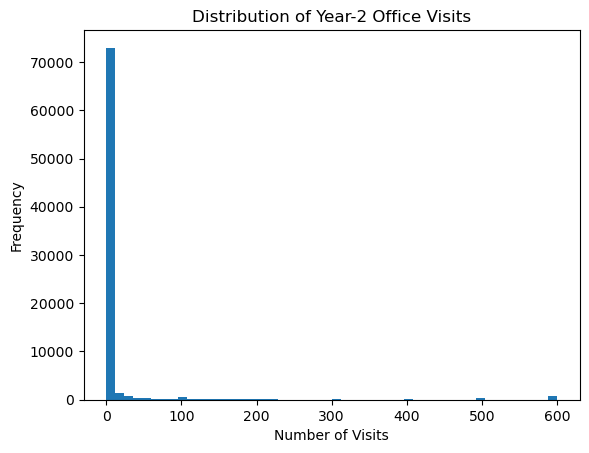

In [76]:
import matplotlib.pyplot as plt

plt.hist(df_final["OBTOTVY2"], bins=50)

plt.title("Distribution of Year-2 Office Visits")
plt.xlabel("Number of Visits")
plt.ylabel("Frequency")

plt.show()

In [77]:
bins = [-1, 0, 2, 5, 10, 20, float("inf")]

labels = [
    "0 visits",
    "1–2 visits",
    "3–5 visits",
    "6–10 visits",
    "11–20 visits",
    "21+ visits"
]

df_final["visit_category"] = pd.cut(
    df_final["OBTOTVY2"],
    bins=bins,
    labels=labels
)

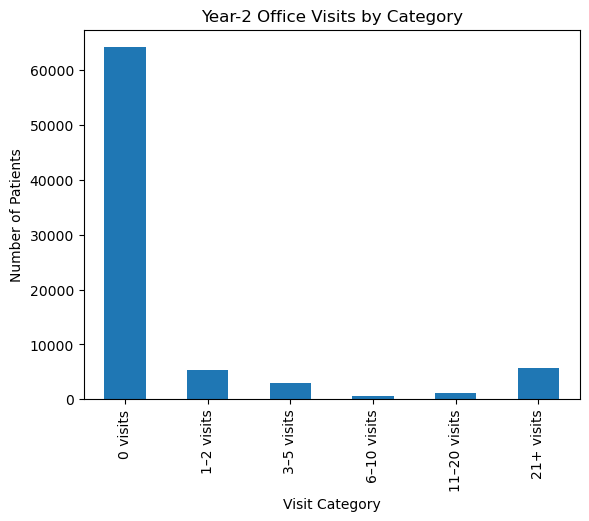

In [324]:
df_final["visit_category"].value_counts().sort_index().plot(kind="bar")

plt.title("Year-2 Office Visits by Category")
plt.xlabel("Visit Category")
plt.ylabel("Number of Patients")

plt.savefig("figure_1_distribution_visits.png", bbox_inches="tight")
plt.show()


C:\Users\abhin\AppData\Local\Temp\ipykernel_23184\558408069.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby("age_group")["OBTOTVY2"].mean().plot(kind="bar")


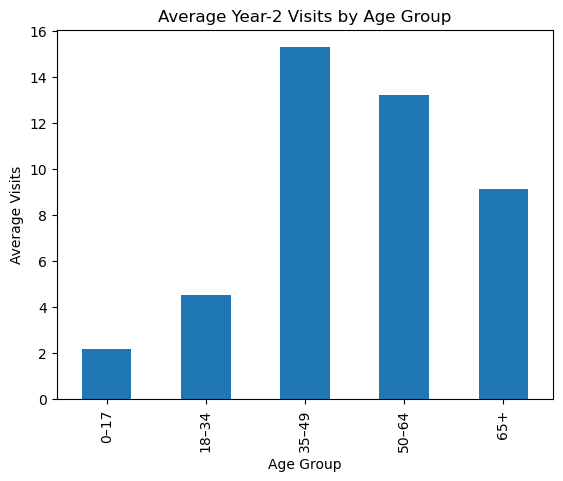

In [326]:
df_final["age_group"] = pd.cut(
    df_final["AGE1X"],
    bins=[0, 18, 35, 50, 65, 85],
    labels=["0–17", "18–34", "35–49", "50–64", "65+"]
)

df_final.groupby("age_group")["OBTOTVY2"].mean().plot(kind="bar")

plt.title("Average Year-2 Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Visits")

plt.savefig("figure_9_age_visits.png", bbox_inches="tight")
plt.show()

In [80]:
chronic_cols = [
    "HIBPDXY1",
    "DIABDXY1",
    "ARTHDXY1",
    "ASTHDXY1",
    "CHDDXY1",
    "MIDXY1",
    "STRKDXY1",
    "EMPHDXY1",
    "CHOLDXY1"
]

df_final["chronic_count"] = (
    df_final[chronic_cols] == 1
).sum(axis=1)

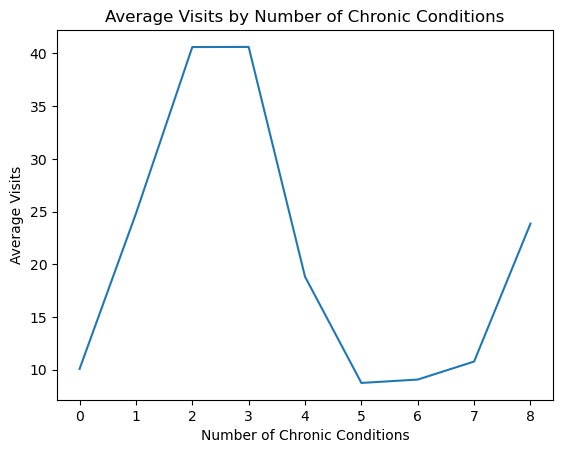

In [81]:
df_final.groupby("chronic_count")["OBTOTVY2"].mean().plot()

plt.title("Average Visits by Number of Chronic Conditions")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Average Visits")

plt.show()

In [82]:
df_final["chronic_count"].value_counts().sort_index()

chronic_count
0    53539
1    20340
2     6250
3     1991
4      537
5      231
6       88
7       24
8       10
Name: count, dtype: int64

C:\Users\abhin\AppData\Local\Temp\ipykernel_23184\1276703121.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby("chronic_group")["OBTOTVY2"].mean().plot(kind="bar")


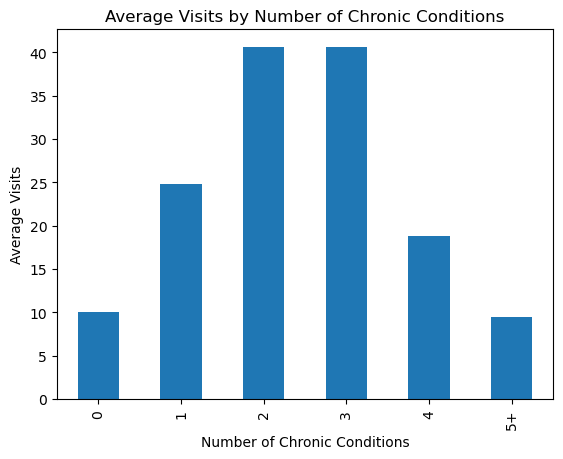

In [328]:
df_final["chronic_group"] = pd.cut(
    df_final["chronic_count"],
    bins=[-1, 0, 1, 2, 3, 4, 10],
    labels=[
        "0",
        "1",
        "2",
        "3",
        "4",
        "5+"
    ]
)

df_final.groupby("chronic_group")["OBTOTVY2"].mean().plot(kind="bar")

plt.title("Average Visits by Number of Chronic Conditions")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Average Visits")

plt.savefig("figure_2_chronic_count.png", bbox_inches="tight")
plt.show()

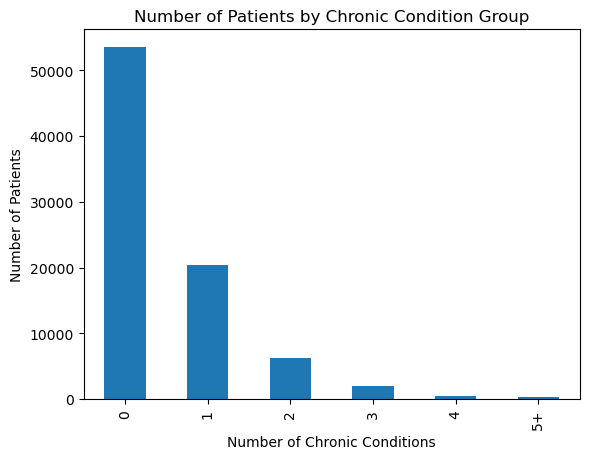

In [84]:
df_final["chronic_group"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Patients by Chronic Condition Group")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Number of Patients")

plt.show()

In [85]:
conditions = [
    "HIBPDXY1",
    "DIABDXY1",
    "ARTHDXY1",
    "JTPAIN1",
    "ASTHDXY1",
    "CHDDXY1",
    "MIDXY1",
    "STRKDXY1",
    "EMPHDXY1",
    "CHOLDXY1"
]

In [86]:
condition_visits = {}

for cond in conditions:
    avg_visits = df_final.loc[
        df_final[cond] == 1,
        "OBTOTVY2"
    ].mean()

    condition_visits[cond] = avg_visits

In [87]:
import pandas as pd

cond_df = pd.DataFrame.from_dict(
    condition_visits,
    orient="index",
    columns=["Average Visits"]
)

cond_df = cond_df.sort_values(
    by="Average Visits",
    ascending=False
)

In [88]:
df_final["REGION1"].value_counts()

REGION1
0.0    26695
3.0    12810
4.0     9482
2.0     6280
1.0     5589
Name: count, dtype: int64

In [294]:
col_labels = {

    # Demographics
    "AGE1X": "Age",
    "SEX": "Sex",
    "RACEV1X": "Race",
    "HISPANX": "Hispanic Ethnicity",
    "REGION1": "Region",

    # Socioeconomic
    "POVCATY1": "Poverty Category",
    "EDRECODE": "Education Level",
    "INSCOVY1": "Insurance Coverage",
    "EMPST1": "Employment Status",
    "ADSMOK2": "Smoking Status",

    # Health status
    "RTHLTH1": "Self-Reported Physical Health",
    "MNHLTH1": "Self-Reported Mental Health",

    # Chronic conditions
    "HIBPDXY1": "Hypertension",
    "DIABDXY1": "Diabetes",
    "ARTHDXY1": "Arthritis",
    "JTPAIN1": "Joint Pain",
    "ASTHDXY1": "Asthma",
    "ASSTIL1": "Still Has Asthma",
    "ASATAK1": "Asthma Attack",
    "CHDDXY1": "Coronary Heart Disease",
    "MIDXY1": "Heart Attack",
    "STRKDXY1": "Stroke",
    "EMPHDXY1": "Emphysema",
    "CHOLDXY1": "High Cholesterol",

    # Utilization
    "OBTOTVY1": "Year-1 Office Visits",
    "OBTOTVY2": "Year-2 Office Visits",
    "OBDRVY1": "Physician Visits",
    "OBNURSY1": "Nurse Practitioner Visits",
    "OBOPTOY1": "Optometrist Visits",
    "OBOTHVY1": "Other Provider Visits",
    "OBTHERY1": "Therapy Visits",

    # Expenditures
    "OBVEXPY1": "Total Office-Based Expenditure",
    "OBDEXPY1": "Doctor Expenditure",
    "OBVTCHY1": "Provider Charges",
    "OBDTCHY1": "Physician Charges"
}

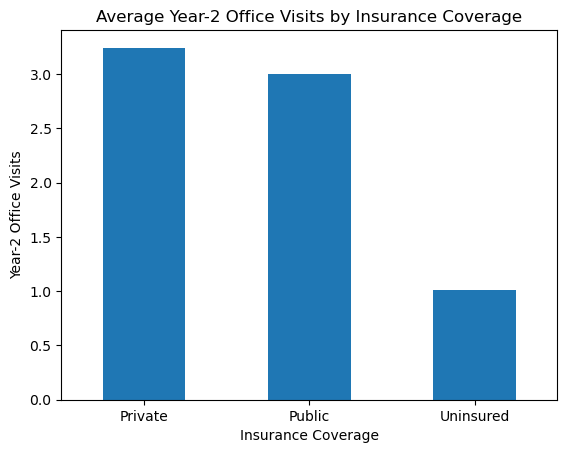

In [90]:
insurance_labels = {
    1: "Private",
    2: "Public",
    3: "Uninsured"
}

ax = (
    df_final.groupby("INSCOVY1")["OBTOTVY2"]
    .mean()
    .rename(index=insurance_labels)
    .plot(kind="bar")
)

plt.title(
    f"Average {col_labels['OBTOTVY2']} by {col_labels['INSCOVY1']}"
)

plt.xlabel(col_labels["INSCOVY1"])
plt.ylabel(col_labels["OBTOTVY2"])

plt.xticks(rotation=0)

plt.show()

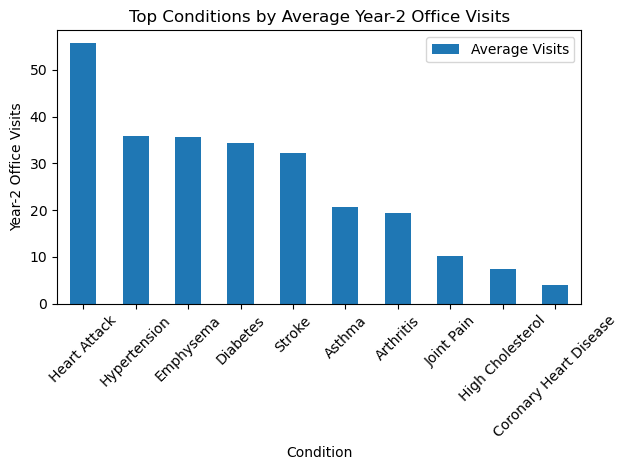

In [330]:
# Replace index codes with readable names
cond_df_plot = cond_df.copy()
cond_df_plot.index = cond_df_plot.index.map(
    lambda x: col_labels.get(x, x)
)

cond_df_plot.head(10).plot(kind="bar")

plt.title(
    f"Top Conditions by Average {col_labels['OBTOTVY2']}"
)

plt.xlabel("Condition")

plt.ylabel(
    col_labels["OBTOTVY2"]
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("figure_3_top_conditions.png", bbox_inches="tight")
plt.show()

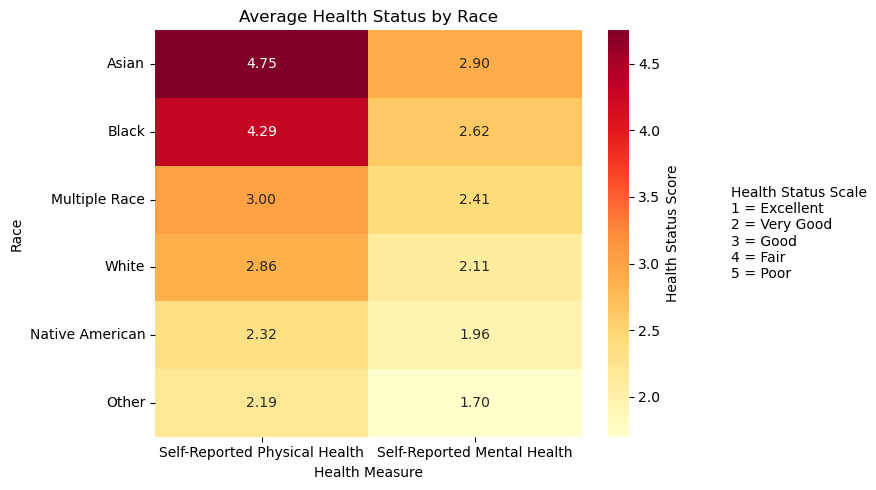

In [332]:
import seaborn as sns

# -----------------------------
# Step 1 — Keep only valid race codes
# -----------------------------
valid_races = [1, 2, 3, 4, 5, 6]

df_final["RACEV1X_clean"] = df_final["RACEV1X"].where(
    df_final["RACEV1X"].isin(valid_races)
)

# -----------------------------
# Step 2 — Compute average health status by race
# -----------------------------
health_by_race = (
    df_final
    .groupby("RACEV1X_clean")[["RTHLTH1", "MNHLTH1"]]
    .mean()
)

# -----------------------------
# Step 3 — Map readable race labels
# -----------------------------
race_labels = {
    1: "White",
    2: "Black",
    3: "Asian",
    4: "Native American",
    5: "Multiple Race",
    6: "Other"
}

health_by_race.index = health_by_race.index.map(
    lambda x: race_labels.get(x, "Unknown")
)

# -----------------------------
# Step 4 — Use readable column labels
# -----------------------------
health_by_race.columns = [
    col_labels["RTHLTH1"],
    col_labels["MNHLTH1"]
]

# -----------------------------
# Step 5 — Sort by physical health
# -----------------------------
health_by_race = health_by_race.sort_values(
    by=col_labels["RTHLTH1"],
    ascending=False
)

# -----------------------------
# Step 6 — Plot heatmap
# -----------------------------
plt.figure(figsize=(9, 5))

sns.heatmap(
    health_by_race,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "Health Status Score"}
)

plt.title("Average Health Status by Race")

plt.xlabel("Health Measure")
plt.ylabel("Race")

# -----------------------------
# Step 7 — Text-only legend
# -----------------------------
legend_text = (
    "Health Status Scale\n"
    "1 = Excellent\n"
    "2 = Very Good\n"
    "3 = Good\n"
    "4 = Fair\n"
    "5 = Poor"
)

plt.text(
    1.35, 0.5,
    legend_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="center"
)

plt.tight_layout()

plt.savefig("figure_5_health_by_race.png", bbox_inches="tight")
plt.show()

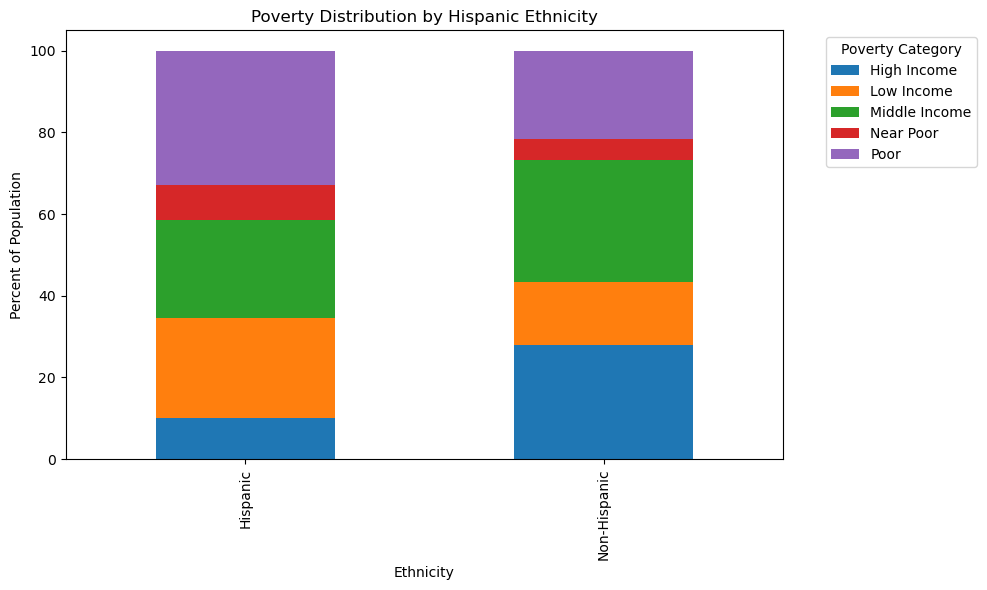

In [334]:
# Keep valid ethnicity codes
valid_hispanic = [1, 2]

df_plot = df_final[
    df_final["HISPANX"].isin(valid_hispanic)
].copy()

# Map labels
ethnicity_labels = {
    1: "Hispanic",
    2: "Non-Hispanic"
}

poverty_labels = {
    1: "Poor",
    2: "Near Poor",
    3: "Low Income",
    4: "Middle Income",
    5: "High Income"
}

df_plot["Ethnicity"] = df_plot["HISPANX"].map(ethnicity_labels)
df_plot["Poverty Category"] = df_plot["POVCATY1"].map(poverty_labels)

# Create percentage distribution
poverty_dist = (
    pd.crosstab(
        df_plot["Ethnicity"],
        df_plot["Poverty Category"],
        normalize="index"
    ) * 100
)

# Plot
poverty_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Poverty Distribution by Hispanic Ethnicity")

plt.xlabel("Ethnicity")
plt.ylabel("Percent of Population")

plt.legend(
    title="Poverty Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("figure_8_poverty_hispanic.png", bbox_inches="tight")
plt.show()

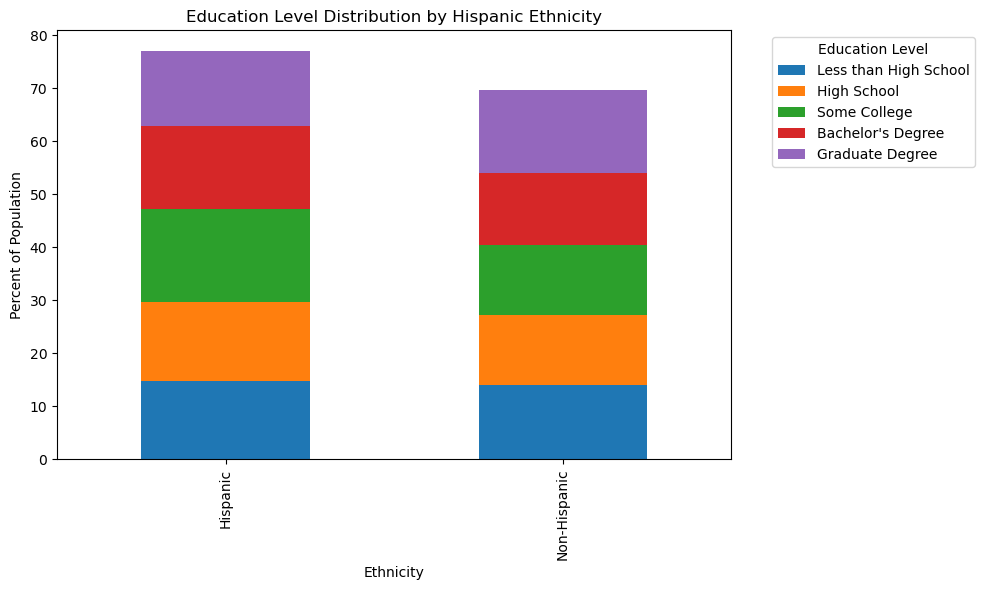

In [336]:
# -----------------------------
# Step 1 — Keep valid ethnicity codes
# -----------------------------
valid_hispanic = [1, 2]

df_plot = df_final[
    df_final["HISPANX"].isin(valid_hispanic)
].copy()

# -----------------------------
# Step 2 — Map readable labels
# -----------------------------
ethnicity_labels = {
    1: "Hispanic",
    2: "Non-Hispanic"
}

education_labels = {
    0: "No School / Unknown",
    1: "Less than High School",
    2: "High School",
    3: "Some College",
    4: "Bachelor's Degree",
    5: "Graduate Degree"
}

df_plot["Ethnicity"] = df_plot["HISPANX"].map(ethnicity_labels)
df_plot["Education Level"] = df_plot["EDRECODE"].map(education_labels)

# Remove missing mappings
df_plot = df_plot.dropna(subset=["Education Level"])

# -----------------------------
# Step 3 — Compute percentages
# -----------------------------
education_dist = (
    pd.crosstab(
        df_plot["Ethnicity"],
        df_plot["Education Level"],
        normalize="index"
    ) * 100
)

# Optional — order columns logically
education_order = [
    "Less than High School",
    "High School",
    "Some College",
    "Bachelor's Degree",
    "Graduate Degree"
]

education_dist = education_dist[
    [col for col in education_order if col in education_dist.columns]
]

# -----------------------------
# Step 4 — Plot stacked bar chart
# -----------------------------
education_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Education Level Distribution by Hispanic Ethnicity")

plt.xlabel("Ethnicity")
plt.ylabel("Percent of Population")

plt.legend(
    title="Education Level",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("figure_7_education_hispanic.png", bbox_inches="tight")
plt.show()


C:\Users\abhin\AppData\Local\Temp\ipykernel_23184\3253753332.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Age Group")["OBTOTVY2"]


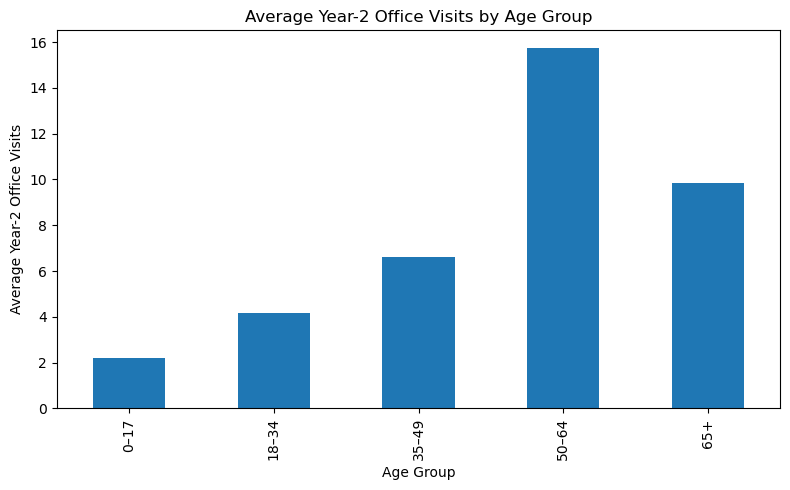

In [115]:
# -----------------------------
# Create age groups
# -----------------------------
age_bins = [0, 17, 34, 49, 64, 120]

age_labels = [
    "0–17",
    "18–34",
    "35–49",
    "50–64",
    "65+"
]

df_final["Age Group"] = pd.cut(
    df_final["AGE1X"],
    bins=age_bins,
    labels=age_labels
)

# -----------------------------
# Compute average utilization
# -----------------------------
age_util = (
    df_final
    .groupby("Age Group")["OBTOTVY2"]
    .mean()
)

# -----------------------------
# Plot
# -----------------------------
age_util.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Year-2 Office Visits by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Average Year-2 Office Visits")

plt.tight_layout()
plt.show()

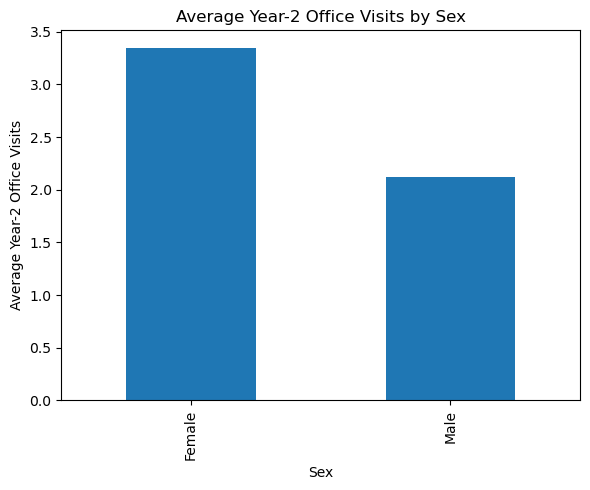

In [338]:
sex_labels = {
    1: "Male",
    2: "Female"
}

df_final["Sex"] = df_final["SEX"].map(sex_labels)

sex_util = (
    df_final
    .groupby("Sex")["OBTOTVY2"]
    .mean()
)

sex_util.plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("Average Year-2 Office Visits by Sex")

plt.xlabel("Sex")
plt.ylabel("Average Year-2 Office Visits")

plt.tight_layout()
plt.savefig("figure_10_sex_visits.png", bbox_inches="tight")
plt.show()


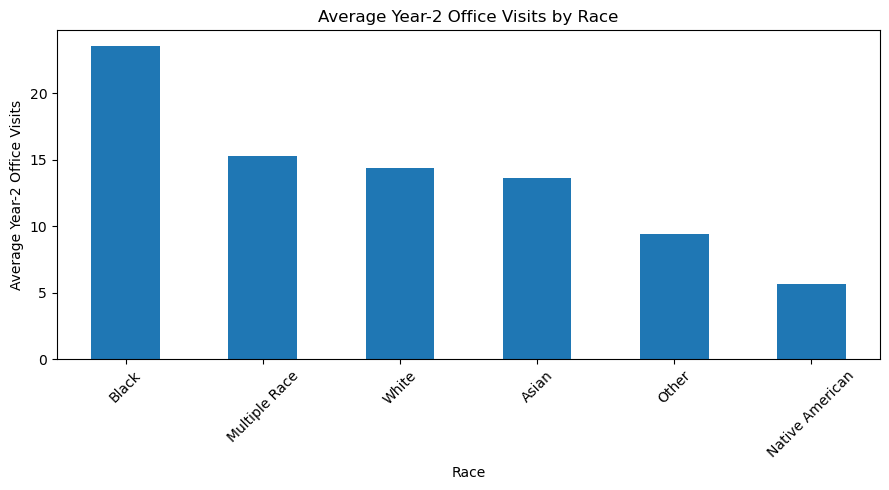

In [340]:
race_labels = {
    1: "White",
    2: "Black",
    3: "Asian",
    4: "Native American",
    5: "Multiple Race",
    6: "Other"
}

df_final["Race"] = df_final["RACEV1X"].map(race_labels)

race_util = (
    df_final
    .groupby("Race")["OBTOTVY2"]
    .mean()
    .sort_values(ascending=False)
)

race_util.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Year-2 Office Visits by Race")

plt.xlabel("Race")
plt.ylabel("Average Year-2 Office Visits")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("figure_11_race_visits.png", bbox_inches="tight")
plt.show()


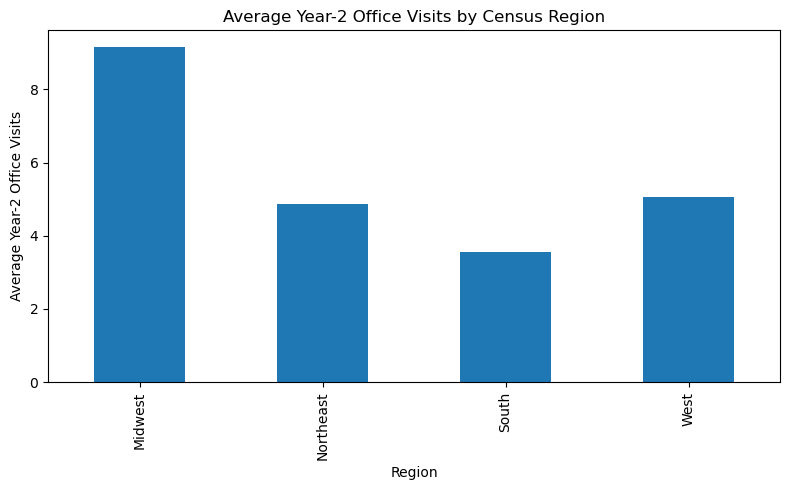

In [342]:
region_labels = {
    1: "Northeast",
    2: "Midwest",
    3: "South",
    4: "West"
}

df_final["Region"] = df_final["REGION1"].map(region_labels)

region_util = (
    df_final
    .groupby("Region")["OBTOTVY2"]
    .mean()
)

region_util.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Year-2 Office Visits by Census Region")

plt.xlabel("Region")
plt.ylabel("Average Year-2 Office Visits")

plt.tight_layout()
plt.savefig("figure_12_region_visits.png", bbox_inches="tight")
plt.show()


C:\Users\abhin\AppData\Local\Temp\ipykernel_23184\2258698222.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Age Group")["Any Visit"]


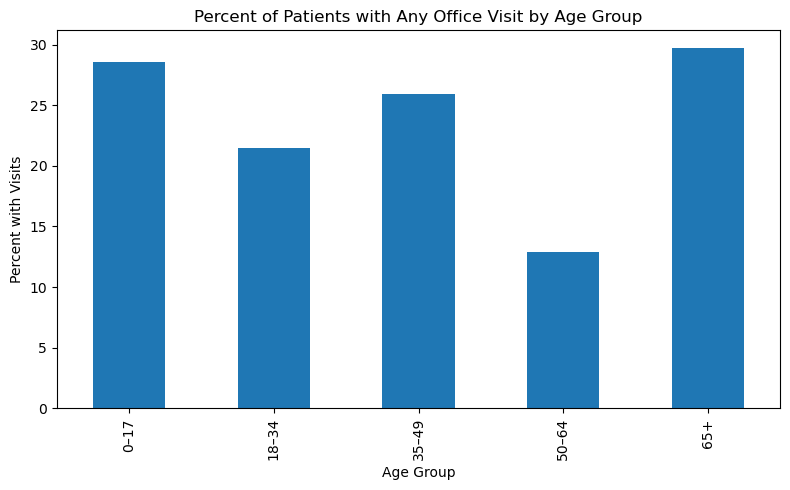

In [123]:
df_final["Any Visit"] = (df_final["OBTOTVY2"] > 0).astype(int)

visit_rate = (
    df_final
    .groupby("Age Group")["Any Visit"]
    .mean()
    * 100
)

visit_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percent of Patients with Any Office Visit by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Percent with Visits")

plt.tight_layout()
plt.show()

In [125]:
chronic_cols = [
    "HIBPDXY1",   # Hypertension
    "DIABDXY1",   # Diabetes
    "ARTHDXY1",   # Arthritis
    "JTPAIN1",    # Joint Pain
    "ASTHDXY1",   # Asthma
    "CHDDXY1",    # Coronary Heart Disease
    "MIDXY1",     # Heart Attack
    "STRKDXY1",   # Stroke
    "EMPHDXY1",   # Emphysema
    "CHOLDXY1"    # High Cholesterol
]

cond_labels = {
    "HIBPDXY1": "Hypertension",
    "DIABDXY1": "Diabetes",
    "ARTHDXY1": "Arthritis",
    "JTPAIN1": "Joint Pain",
    "ASTHDXY1": "Asthma",
    "CHDDXY1": "Coronary Heart Disease",
    "MIDXY1": "Heart Attack",
    "STRKDXY1": "Stroke",
    "EMPHDXY1": "Emphysema",
    "CHOLDXY1": "High Cholesterol"
}

C:\Users\abhin\AppData\Local\Temp\ipykernel_23184\3059597130.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Age Group")[


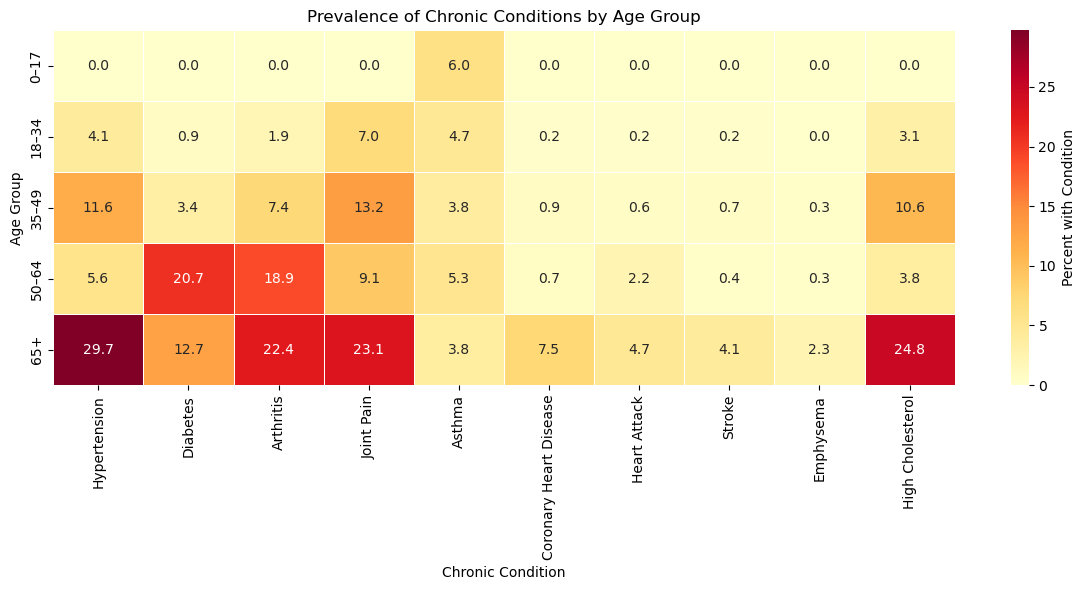

In [344]:
# -----------------------------
# Create age groups
# -----------------------------
age_bins = [0, 17, 34, 49, 64, 120]

age_labels = [
    "0–17",
    "18–34",
    "35–49",
    "50–64",
    "65+"
]

df_final["Age Group"] = pd.cut(
    df_final["AGE1X"],
    bins=age_bins,
    labels=age_labels
)

# -----------------------------
# Convert conditions to binary
# -----------------------------
for col in chronic_cols:
    df_final[col + "_bin"] = (
        df_final[col] == 1
    ).astype(int)

# -----------------------------
# Compute prevalence
# -----------------------------
age_chronic = (
    df_final
    .groupby("Age Group")[
        [c + "_bin" for c in chronic_cols]
    ]
    .mean()
    * 100
)

age_chronic.columns = [
    cond_labels[c] for c in chronic_cols
]

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(12, 6))

sns.heatmap(
    age_chronic,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Percent with Condition"},
    linewidths=0.5
)

plt.title("Prevalence of Chronic Conditions by Age Group")

plt.xlabel("Chronic Condition")
plt.ylabel("Age Group")

plt.tight_layout()
plt.savefig("figure_4_chronic_by_age.png", bbox_inches="tight")
plt.show()


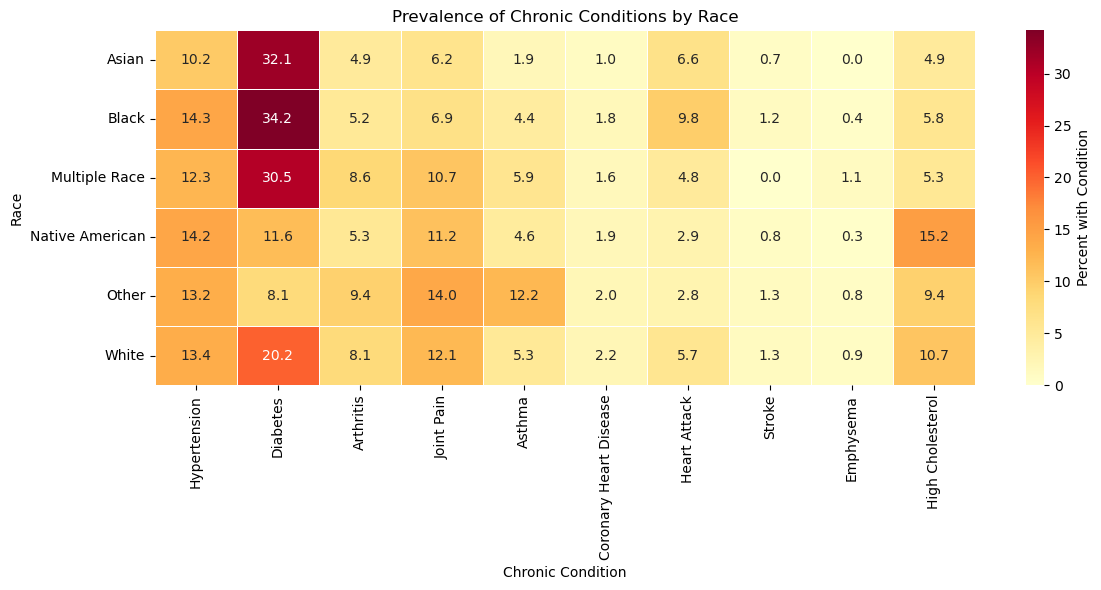

In [346]:
# -----------------------------
# Map race labels
# -----------------------------
race_labels = {
    1: "White",
    2: "Black",
    3: "Asian",
    4: "Native American",
    5: "Multiple Race",
    6: "Other"
}

df_final["Race"] = df_final["RACEV1X"].map(race_labels)

# -----------------------------
# Compute prevalence
# -----------------------------
race_chronic = (
    df_final
    .groupby("Race")[
        [c + "_bin" for c in chronic_cols]
    ]
    .mean()
    * 100
)

race_chronic.columns = [
    cond_labels[c] for c in chronic_cols
]

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(12, 6))

sns.heatmap(
    race_chronic,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "Percent with Condition"},
    linewidths=0.5
)

plt.title("Prevalence of Chronic Conditions by Race")

plt.xlabel("Chronic Condition")
plt.ylabel("Race")

plt.tight_layout()
plt.savefig("figure_6_chronic_by_race.png", bbox_inches="tight")
plt.show()


## Feature Importance

In [134]:
df_final.shape

(83010, 60)

In [136]:
features = [

    # Demographics
    "AGE1X",
    "SEX",
    "RACEV1X",
    "HISPANX",
    "REGION1",

    # Socioeconomic
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "EMPST1",
    "ADSMOK2",

    # Health status
    "RTHLTH1",
    "MNHLTH1",

    # Chronic conditions
    "HIBPDXY1",
    "DIABDXY1",
    "ARTHDXY1",
    "JTPAIN1",
    "ASTHDXY1",
    "CHDDXY1",
    "MIDXY1",
    "STRKDXY1",
    "EMPHDXY1",
    "CHOLDXY1",

    # Prior utilization
    "OBTOTVY1"
]

In [140]:
df_final[features].isna().sum().sort_values(ascending=False)

STRKDXY1    69152
CHOLDXY1    69018
EMPHDXY1    67906
INSCOVY1    66060
ARTHDXY1    65077
ASTHDXY1    64594
JTPAIN1     61645
CHDDXY1     59349
RTHLTH1     54754
MNHLTH1     54156
ADSMOK2     52407
POVCATY1    50317
HIBPDXY1    47505
MIDXY1      37160
SEX         32291
AGE1X       29993
EDRECODE    25181
DIABDXY1    24589
REGION1     22154
RACEV1X     21150
EMPST1      17780
HISPANX      5290
OBTOTVY1     2666
dtype: int64

In [142]:
missing_pct = (
    df_final[features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing_pct)

STRKDXY1    0.833056
CHOLDXY1    0.831442
EMPHDXY1    0.818046
INSCOVY1    0.795808
ARTHDXY1    0.783966
ASTHDXY1    0.778147
JTPAIN1     0.742621
CHDDXY1     0.714962
RTHLTH1     0.659607
MNHLTH1     0.652403
ADSMOK2     0.631334
POVCATY1    0.606156
HIBPDXY1    0.572280
MIDXY1      0.447657
SEX         0.389001
AGE1X       0.361318
EDRECODE    0.303349
DIABDXY1    0.296217
REGION1     0.266884
RACEV1X     0.254789
EMPST1      0.214191
HISPANX     0.063727
OBTOTVY1    0.032117
dtype: float64


In [150]:
df_final["OBTOTVY2"].isna().sum()

3231

In [152]:
df_final["OBTOTVY2"].notna().sum()

79779

In [158]:
df_model = df_final.dropna(subset=["OBTOTVY2"])

print("New shape:", df_model.shape)

New shape: (79779, 60)


In [160]:
X = df_model[features]
y = df_model["OBTOTVY2"]

In [162]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [212]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', LinearRegression())])

In [214]:
print("Final dataset shape:", df_model.shape)

print(
    "Remaining missing predictors:",
    df_model[features].isna().sum().sum()
)

Final dataset shape: (79779, 60)
Remaining missing predictors: 968550


In [216]:
total_cells = df_model[features].size
missing_cells = df_model[features].isna().sum().sum()

print("Percent missing overall:",
      missing_cells / total_cells)

Percent missing overall: 0.5278440387221874


In [218]:
coefficients = pipeline.named_steps["model"].coef_

In [220]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# Use absolute value for importance
importance_df["Importance"] = (
    importance_df["Coefficient"].abs()
)

# Sort from most important to least
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Coefficient,Importance
19,STRKDXY1,-16.422636,16.422636
13,DIABDXY1,-15.804323,15.804323
16,ASTHDXY1,-6.288741,6.288741
15,JTPAIN1,5.245406,5.245406
1,SEX,-2.168645,2.168645
7,INSCOVY1,-1.871883,1.871883
14,ARTHDXY1,1.748903,1.748903
3,HISPANX,-0.804356,0.804356
4,REGION1,0.551126,0.551126
10,RTHLTH1,0.463164,0.463164


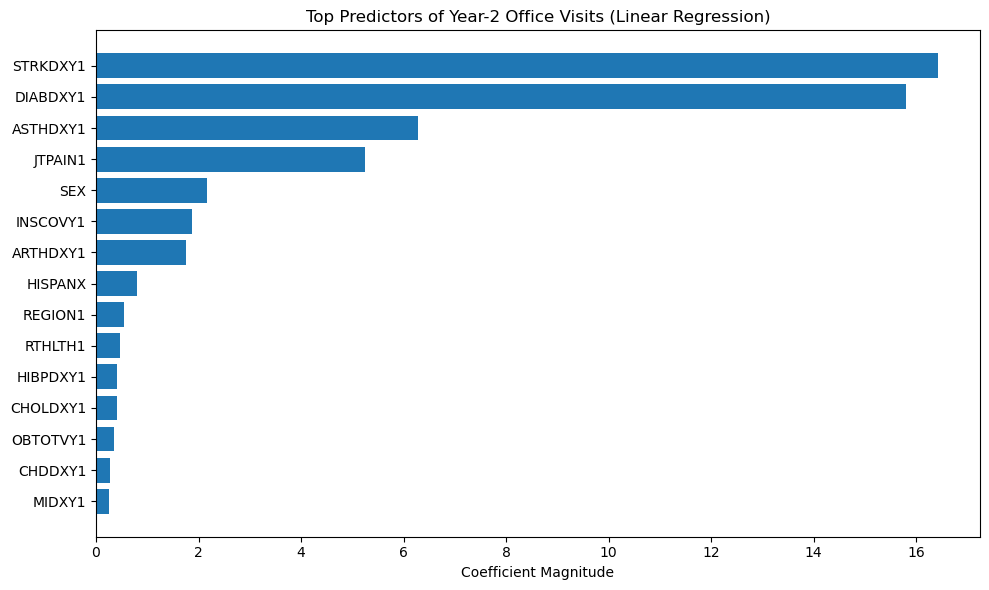

In [222]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Predictors of Year-2 Office Visits (Linear Regression)")

plt.xlabel("Coefficient Magnitude")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Standardizing Predictors

In [225]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [229]:
coefficients = pipeline.named_steps["model"].coef_

importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

importance_df["Importance"] = (
    importance_df["Coefficient"].abs()
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Coefficient,Importance
22,OBTOTVY1,24.771434,24.771434
13,DIABDXY1,-6.560385,6.560385
15,JTPAIN1,3.681375,3.681375
10,RTHLTH1,2.642143,2.642143
17,CHDDXY1,1.647794,1.647794
1,SEX,-1.384955,1.384955
12,HIBPDXY1,-1.269908,1.269908
3,HISPANX,-1.198792,1.198792
19,STRKDXY1,-1.195457,1.195457
16,ASTHDXY1,-1.141985,1.141985


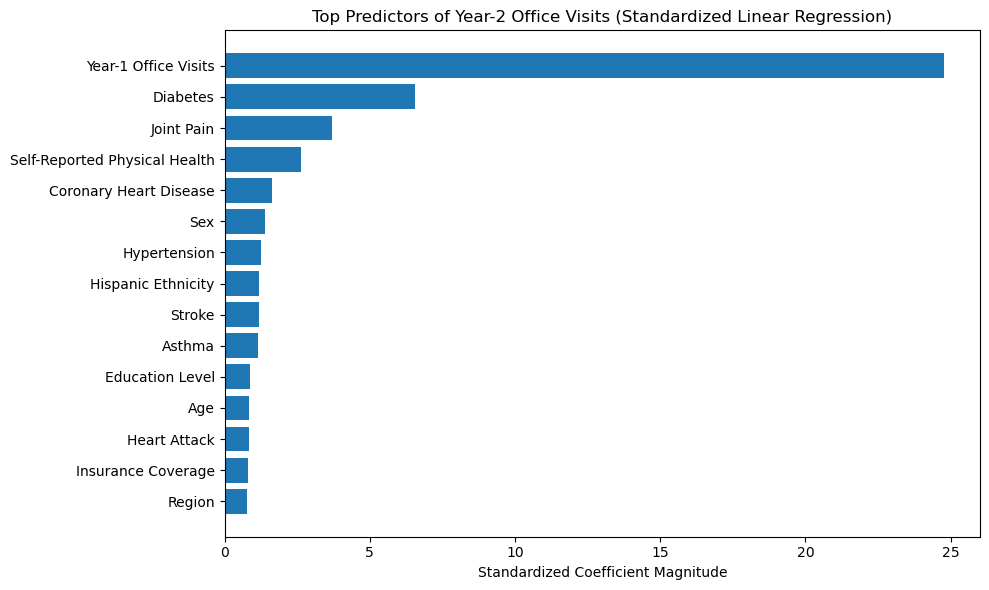

In [348]:
top_features = importance_df.head(15).copy()

# Optional readable labels
top_features["Feature"] = top_features["Feature"].map(
    lambda x: col_labels.get(x, x)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Predictors of Year-2 Office Visits (Standardized Linear Regression)")

plt.xlabel("Standardized Coefficient Magnitude")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("figure_13_feature_importance.png", bbox_inches="tight")

plt.show()


In [233]:
preds = pipeline.predict(X_test)

In [235]:
print("Min prediction:", preds.min())
print("Max prediction:", preds.max())
print("Mean prediction:", preds.mean())

print("Actual mean:", y_test.mean())

Min prediction: -24.41570653707007
Max prediction: 248.115623743638
Mean prediction: 16.889332291756624
Actual mean: 16.351779894710454


In [237]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

print("R²:", r2_score(y_test, preds))

rmse = np.sqrt(((y_test - preds) ** 2).mean())
print("RMSE:", rmse)

print("MAE:", mean_absolute_error(y_test, preds))

R²: 0.13065425896928118
RMSE: 74.00685007846202
MAE: 25.9136982276548


In [247]:
corr_matrix = df_model[features].corr()

pd.set_option("display.max_columns", None)
corr_matrix.head()

,AGE1X,SEX,RACEV1X,HISPANX,REGION1,POVCATY1,EDRECODE,INSCOVY1,EMPST1,ADSMOK2,RTHLTH1,MNHLTH1,HIBPDXY1,DIABDXY1,ARTHDXY1,JTPAIN1,ASTHDXY1,CHDDXY1,MIDXY1,STRKDXY1,EMPHDXY1,CHOLDXY1,OBTOTVY1
AGE1X,1.000000,-0.070806,0.341974,-0.343929,-0.477117,-0.077047,-0.135321,-0.055636,0.023438,-0.094154,0.100822,0.117739,-0.030469,-0.081991,-0.468975,0.250965,-0.221383,0.131048,0.124213,-0.155896,0.202320,-0.309703,0.073334
SEX,-0.070806,1.000000,-0.404049,0.026256,0.264599,0.266560,0.712975,-0.003153,-0.132716,0.793345,-0.198891,-0.124430,-0.090156,0.367490,-0.110581,-0.054656,-0.010330,-0.224005,-0.069714,0.056862,-0.440403,-0.081676,-0.103634
RACEV1X,0.341974,-0.404049,1.000000,-0.214097,-0.302778,-0.290875,-0.212175,-0.059247,0.012367,-0.282936,0.102604,0.078105,0.032184,-0.126103,-0.323993,0.555939,-0.316714,0.113934,0.003225,-0.105991,0.167936,0.119214,0.035995
HISPANX,-0.343929,0.026256,-0.214097,1.000000,0.646480,0.514976,0.458810,-0.269504,-0.174640,0.241792,-0.182431,-0.121759,-0.076411,0.224612,0.448541,-0.487307,0.423928,0.026559,0.303061,0.080370,0.334839,-0.125289,-0.115373
REGION1,-0.477117,0.264599,-0.302778,0.646480,1.000000,0.360978,0.343379,0.059784,-0.175717,0.205013,-0.152918,-0.112190,-0.087169,0.191083,0.455481,-0.450610,0.408195,-0.039281,0.102986,0.038887,0.023904,-0.029633,-0.123776


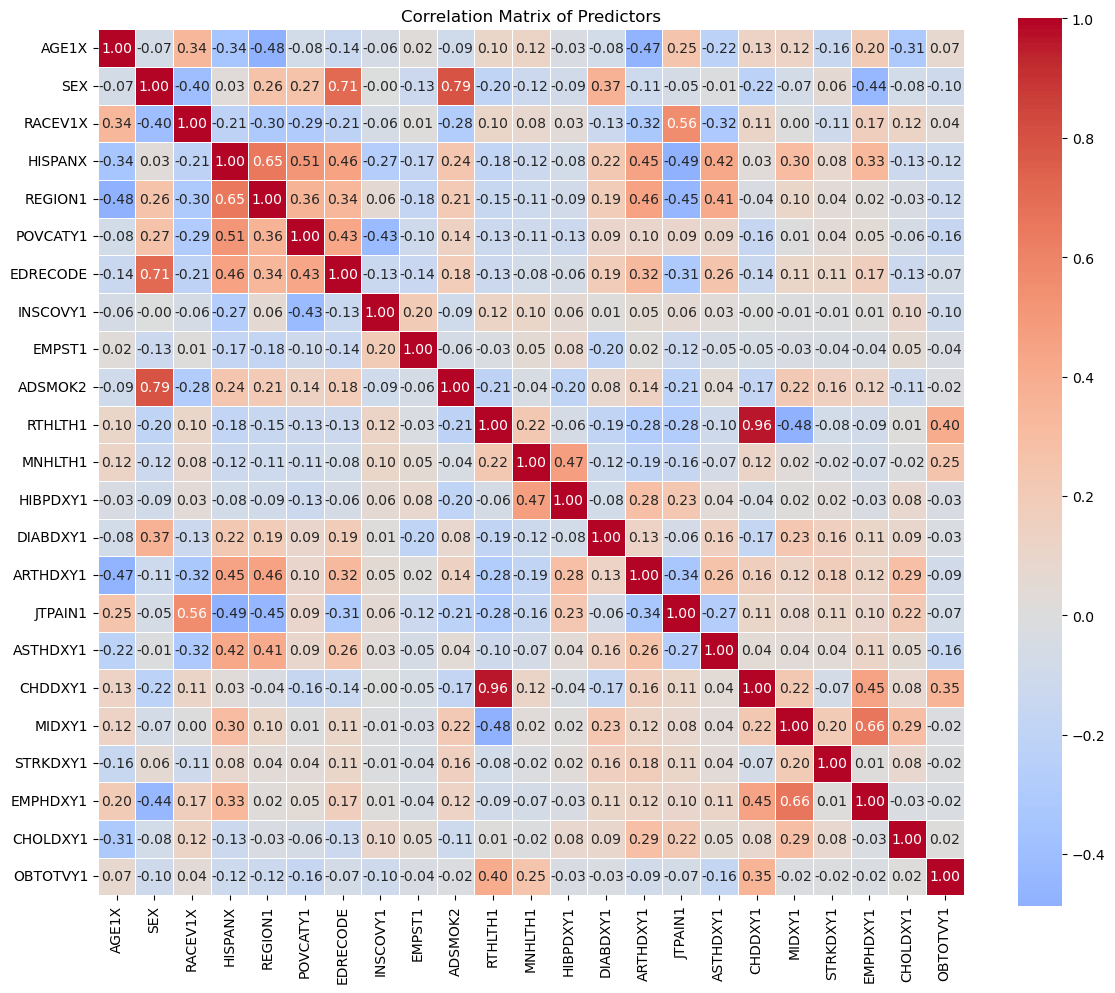

In [350]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    df_model[features].corr(),
    annot=True,          # shows numbers
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Predictors")

plt.tight_layout()
plt.savefig("figure_14_correlation_matrix.png", bbox_inches="tight")
plt.show()


In [251]:
df_final.to_csv("df_final.csv", index=False)

In [252]:
import os

os.listdir()

['.ipynb_checkpoints',
 'df_final.csv',
 'Household Longitudinal Data Files',
 'MEPS_project.ipynb',
 'MEPS_Project_2.ipynb']

In [268]:
import shap
import pandas as pd
import numpy as np

# Use the trained pipeline
model = pipeline

# Use the same data used for training
X_used = X_train

# Create SHAP explainer

explainer = shap.Explainer(
    model.predict,
    X_used
)

# Compute SHAP values

shap_values = explainer(X_used)

# Create SHAP importance table

shap_importance = pd.DataFrame({
    "Feature": X_used.columns,
    "SHAP Importance": np.abs(shap_values.values).mean(axis=0)
})

# Sort

shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)

print(shap_importance.head(15))

PermutationExplainer explainer: 63824it [57:56, 18.32it/s]                             


     Feature  SHAP Importance
22  OBTOTVY1         9.647941
13  DIABDXY1         6.051991
15   JTPAIN1         1.522742
1        SEX         0.932689
3    HISPANX         0.895806
4    REGION1         0.632556
16  ASTHDXY1         0.566266
0      AGE1X         0.556933
7   INSCOVY1         0.368603
10   RTHLTH1         0.363441
6   EDRECODE         0.356673
2    RACEV1X         0.348791
14  ARTHDXY1         0.240945
17   CHDDXY1         0.190448
12  HIBPDXY1         0.120920


In [278]:
col_labels = {
    "AGE1X": "Age",
    "SEX": "Sex",
    "RACEV1X": "Race",
    "HISPANX": "Hispanic Ethnicity",
    "REGION1": "Region",
    "POVCATY1": "Poverty Category",
    "EDRECODE": "Education Level",
    "INSCOVY1": "Insurance Coverage",
    "EMPST1": "Employment Status",
    "ADSMOK2": "Smoking Status",
    "RTHLTH1": "Self-Reported Physical Health",
    "MNHLTH1": "Self-Reported Mental Health",
    "HIBPDXY1": "Hypertension",
    "DIABDXY1": "Diabetes",
    "ARTHDXY1": "Arthritis",
    "JTPAIN1": "Joint Pain",
    "ASTHDXY1": "Asthma",
    "CHDDXY1": "Coronary Heart Disease",
    "MIDXY1": "Heart Attack",
    "STRKDXY1": "Stroke",
    "EMPHDXY1": "Emphysema",
    "CHOLDXY1": "High Cholesterol",
    "OBTOTVY1": "Year-1 Office Visits"
}

In [280]:
shap_importance["Feature"] = shap_importance["Feature"].map(
    lambda x: col_labels.get(x, x)
)

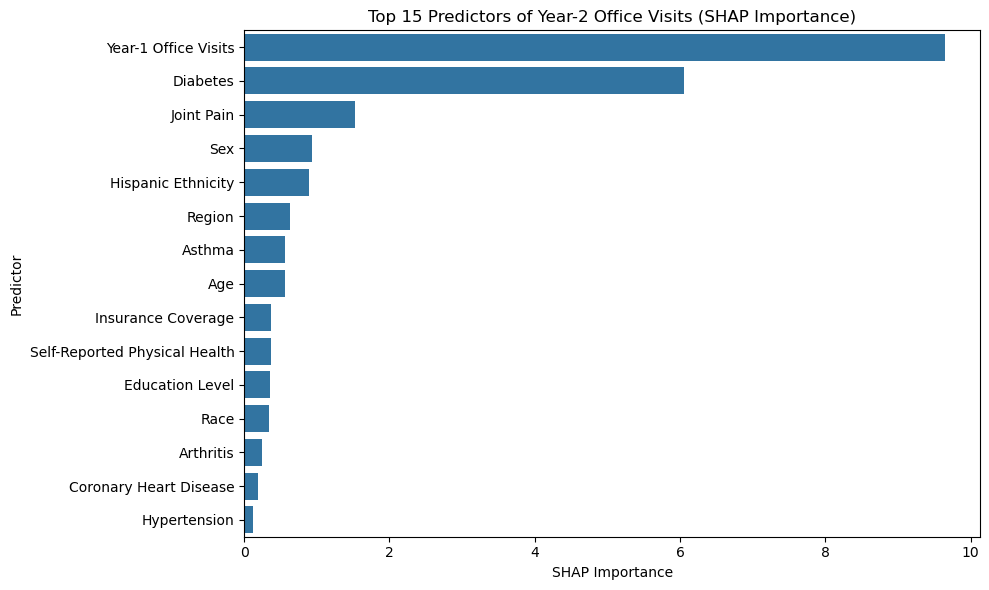

In [352]:
# Sort and select top features

top_features = (
    shap_importance
    .sort_values(by="SHAP Importance", ascending=False)
    .head(15)
)

# Create plot

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="SHAP Importance",
    y="Feature",
    ax=ax
)

ax.set_title("Top 15 Predictors of Year-2 Office Visits (SHAP Importance)")
ax.set_xlabel("SHAP Importance")
ax.set_ylabel("Predictor")

plt.tight_layout()
plt.savefig("figure_15_shap_importance.png", bbox_inches="tight")
plt.show()


In [284]:
shap_importance.to_csv(
    "shap_importance.csv",
    index=False
)

## Base Model

In [70]:
model_vars = [
    "OBTOTVY2",
    "OBTOTVY1",
    "AGE1X",
    "SEX",
    "RACEV1X",
    "REGION1",
    "POVCATY1",
    "INSCOVY1",
    "RTHLTH1",
    "MNHLTH1"
]

df_model = df_final[model_vars].dropna()

print(df_model.shape)

(79963, 10)


In [71]:
print(df_model["OBTOTVY2"].describe())
print("Negative values:", (df_model["OBTOTVY2"] < 0).sum())
print("Percent zero:", (df_model["OBTOTVY2"] == 0).mean())

count    79963.000000
mean         4.320236
std          9.916816
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max        367.000000
Name: OBTOTVY2, dtype: float64
Negative values: 0
Percent zero: 0.3418581093755862


In [72]:
print(df_model.describe())

           OBTOTVY2      OBTOTVY1         AGE1X           SEX       RACEV1X  \
count  79963.000000  79963.000000  79963.000000  79963.000000  79963.000000   
mean       4.320236      4.127046     33.838800      1.521291      1.616798   
std        9.916816      9.544737     22.008743      0.499550      1.157631   
min        0.000000      0.000000      0.000000      1.000000      1.000000   
25%        0.000000      0.000000     15.000000      1.000000      1.000000   
50%        1.000000      1.000000     32.000000      2.000000      1.000000   
75%        4.000000      4.000000     51.000000      2.000000      2.000000   
max      367.000000    391.000000     85.000000      2.000000      6.000000   

            REGION1      POVCATY1      INSCOVY1       RTHLTH1      MNHLTH1  
count  79963.000000  79963.000000  79963.000000  79963.000000  79963.00000  
mean       2.782524      3.207571      1.646049      2.162338      1.86520  
std        1.026658      1.492830      0.738443      1.10

In [73]:
mean_y = df_model["OBTOTVY2"].mean()
var_y = df_model["OBTOTVY2"].var()

print("Mean:", mean_y)
print("Variance:", var_y)
print("Variance / Mean:", var_y / mean_y)

Mean: 4.320235608969148
Variance: 98.34324712692255
Variance / Mean: 22.7633990430416


In [74]:
print(df_model[["OBTOTVY1", "OBTOTVY2"]].corr())

          OBTOTVY1  OBTOTVY2
OBTOTVY1  1.000000  0.661503
OBTOTVY2  0.661503  1.000000


In [75]:
import statsmodels.api as sm

X = df_model[[
    "OBTOTVY1",
    "AGE1X",
    "SEX",
    "RACEV1X",
    "REGION1",
    "POVCATY1",
    "INSCOVY1",
    "RTHLTH1",
    "MNHLTH1"
]]

X = sm.add_constant(X)
y = df_model["OBTOTVY2"]

model_nb = sm.NegativeBinomial(y, X).fit(maxiter=200)

print(model_nb.summary())

Optimization terminated successfully.
         Current function value: 421.402682
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1


C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:3615: RuntimeWarning: invalid value encountered in divide
  dada = (da2 * dalpha/da1 + da1**2 * (special.polygamma(1, a1+y) -
C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:3615: RuntimeWarning: invalid value encountered in subtract
  dada = (da2 * dalpha/da1 + da1**2 * (special.polygamma(1, a1+y) -
C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:3615: RuntimeWarning: invalid value encountered in multiply
  dada = (da2 * dalpha/da1 + da1**2 * (special.polygamma(1, a1+y) -
C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                     NegativeBinomial Regression Results                      
Dep. Variable:               OBTOTVY2   No. Observations:                79963
Model:               NegativeBinomial   Df Residuals:                    79953
Method:                           MLE   Df Model:                            9
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  -173.4
Time:                        13:10:14   Log-Likelihood:            -3.3697e+07
converged:                       True   LL-Null:                   -1.9317e+05
Covariance Type:            nonrobust   LLR p-value:                     1.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0384        nan        nan        nan         nan         nan
OBTOTVY1       0.0413        nan        nan        nan         nan         nan
AGE1X          0.0238        nan        nan        n

In [76]:
import statsmodels.api as sm

X = df_model[[
    "OBTOTVY1",
    "AGE1X",
    "SEX",
    "RACEV1X",
    "REGION1",
    "POVCATY1",
    "INSCOVY1",
    "RTHLTH1",
    "MNHLTH1"
]]

X = sm.add_constant(X)
y = df_model["OBTOTVY2"]

model_nb = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(model_nb.summary())

C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:               OBTOTVY2   No. Observations:                79963
Model:                            GLM   Df Residuals:                    79953
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7981e+05
Date:                Fri, 06 Mar 2026   Deviance:                   1.0525e+05
Time:                        13:10:16   Pearson chi2:                 2.05e+05
No. Iterations:                    34   Pseudo R-squ. (CS):             0.4752
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2150      0.028      7.716      0.0

In [77]:
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
).fit()

print("Poisson AIC:", poisson_model.aic)
print("NB AIC:", model_nb.aic)

Poisson AIC: 703990.5320096301
NB AIC: 359636.8487289889


In [78]:
np.exp(model_nb.params)

const       1.239888
OBTOTVY1    1.079663
AGE1X       1.010276
SEX         1.311536
RACEV1X     0.983513
REGION1     0.951928
POVCATY1    1.015197
INSCOVY1    0.777899
RTHLTH1     1.100623
MNHLTH1     1.056624
dtype: float64

In [79]:
for col in ["ASTHDXY1", "ARTHDXY1", "HIBPDXY1", "DIABDXY1"]:
    df_final[col] = df_final[col].map({1:1, 2:0})
    df_final[col] = df_final[col].fillna(0)

In [80]:
chronic_vars = [
    "HIBPDXY1",
    "DIABDXY1",
    "ARTHDXY1",
    "ASTHDXY1",
    "CHDDXY1",
    "MIDXY1",
    "STRKDXY1",
    "EMPHDXY1",
    "CHOLDXY1"
]

model_vars_extended = [
    "OBTOTVY2",
    "OBTOTVY1",
    "AGE1X",
    "SEX",
    "RACEV1X",
    "REGION1",
    "POVCATY1",
    "INSCOVY1",
    "RTHLTH1",
    "MNHLTH1"
] + chronic_vars

In [81]:
df_model_ext = df_final[model_vars_extended].dropna(
    subset=[
        "OBTOTVY2","OBTOTVY1",
        "AGE1X","SEX","RACEV1X",
        "REGION1","POVCATY1",
        "INSCOVY1","RTHLTH1","MNHLTH1"
    ]
)

print("Extended shape:", df_model_ext.shape)

Extended shape: (79963, 19)


In [117]:
import statsmodels.api as sm

X_ext = sm.add_constant(
    df_model_ext.drop(columns="OBTOTVY2")
)
y_ext = df_model_ext["OBTOTVY2"]

model_nb_ext = sm.GLM(
    y_ext,
    X_ext,
    family=sm.families.NegativeBinomial()
).fit()

print(model_nb_ext.summary())

C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


MissingDataError: exog contains inf or nans

In [119]:
print(df_model_ext.isna().sum())

OBTOTVY2        0
OBTOTVY1        0
AGE1X           0
SEX             0
RACEV1X         0
REGION1         0
POVCATY1        0
INSCOVY1        0
RTHLTH1         0
MNHLTH1         0
HIBPDXY1        0
DIABDXY1        0
ARTHDXY1        0
ASTHDXY1        0
CHDDXY1     22462
MIDXY1      22454
STRKDXY1    22450
EMPHDXY1    22451
CHOLDXY1    22490
dtype: int64


In [121]:
print(X_ext.isna().sum())

const           0
OBTOTVY1        0
AGE1X           0
SEX             0
RACEV1X         0
REGION1         0
POVCATY1        0
INSCOVY1        0
RTHLTH1         0
MNHLTH1         0
HIBPDXY1        0
DIABDXY1        0
ARTHDXY1        0
ASTHDXY1        0
CHDDXY1     22462
MIDXY1      22454
STRKDXY1    22450
EMPHDXY1    22451
CHOLDXY1    22490
dtype: int64


In [123]:
chronic_vars = [
    "HIBPDXY1","DIABDXY1","ARTHDXY1","ASTHDXY1",
    "CHDDXY1","MIDXY1","STRKDXY1","EMPHDXY1","CHOLDXY1"
]

for col in chronic_vars:
    df_final[col] = df_final[col].map({1:1, 2:0})
    df_final[col] = df_final[col].fillna(0)

In [125]:
print(df_final[chronic_vars].isna().sum())

HIBPDXY1    0
DIABDXY1    0
ARTHDXY1    0
ASTHDXY1    0
CHDDXY1     0
MIDXY1      0
STRKDXY1    0
EMPHDXY1    0
CHOLDXY1    0
dtype: int64


In [127]:
df_model_ext = df_final[model_vars_extended].dropna(
    subset=[
        "OBTOTVY2","OBTOTVY1",
        "AGE1X","SEX","RACEV1X",
        "REGION1","POVCATY1",
        "INSCOVY1","RTHLTH1","MNHLTH1"
    ]
)

In [129]:
print(df_model_ext.isna().sum().sum())

0


In [131]:
X_ext = sm.add_constant(
    df_model_ext.drop(columns="OBTOTVY2")
)
y_ext = df_model_ext["OBTOTVY2"]

model_nb_ext = sm.GLM(
    y_ext,
    X_ext,
    family=sm.families.NegativeBinomial()
).fit()

print(model_nb_ext.summary())

C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:               OBTOTVY2   No. Observations:                79963
Model:                            GLM   Df Residuals:                    79944
Model Family:        NegativeBinomial   Df Model:                           18
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7881e+05
Date:                Fri, 06 Mar 2026   Deviance:                   1.0326e+05
Time:                        13:24:38   Pearson chi2:                 2.06e+05
No. Iterations:                    32   Pseudo R-squ. (CS):             0.4881
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2677      0.028      9.512      0.0

### Corr Coeffs

In [133]:
import numpy as np

corr_matrix = df_model_ext.corr(numeric_only=True)

# Print correlations with outcome
print(corr_matrix["OBTOTVY2"].sort_values(ascending=False))

OBTOTVY2    1.000000
OBTOTVY1    0.661503
ARTHDXY1    0.248285
AGE1X       0.218586
HIBPDXY1    0.195100
CHOLDXY1    0.192213
RTHLTH1     0.175167
DIABDXY1    0.155748
MNHLTH1     0.142156
CHDDXY1     0.124899
STRKDXY1    0.107083
MIDXY1      0.095984
ASTHDXY1    0.088122
SEX         0.082863
EMPHDXY1    0.063602
POVCATY1    0.060770
RACEV1X    -0.025417
REGION1    -0.047961
INSCOVY1   -0.088715
Name: OBTOTVY2, dtype: float64


In [136]:
# Check Correlation Among Predictors

predictors = [
    "OBTOTVY1", "AGE1X", "SEX", "RACEV1X", "REGION1",
    "POVCATY1", "INSCOVY1", "RTHLTH1", "MNHLTH1",
    "HIBPDXY1", "DIABDXY1", "ARTHDXY1", "ASTHDXY1",
    "CHDDXY1", "MIDXY1", "STRKDXY1", "EMPHDXY1", "CHOLDXY1"
]

corr_pred = df_model_ext[predictors].corr()

print(corr_pred.round(3))

          OBTOTVY1  AGE1X    SEX  RACEV1X  REGION1  POVCATY1  INSCOVY1  \
OBTOTVY1     1.000  0.203  0.079   -0.027   -0.042     0.058    -0.100   
AGE1X        0.203  1.000  0.056   -0.044   -0.035     0.210    -0.062   
SEX          0.079  0.056  1.000    0.002   -0.005    -0.061    -0.013   
RACEV1X     -0.027 -0.044  0.002    1.000    0.022     0.031    -0.059   
REGION1     -0.042 -0.035 -0.005    0.022    1.000    -0.013     0.047   
POVCATY1     0.058  0.210 -0.061    0.031   -0.013     1.000    -0.452   
INSCOVY1    -0.100 -0.062 -0.013   -0.059    0.047    -0.452     1.000   
RTHLTH1      0.189  0.359  0.052   -0.027   -0.010    -0.121     0.118   
MNHLTH1      0.151  0.238  0.033   -0.024   -0.033    -0.137     0.111   
HIBPDXY1     0.189  0.545  0.014   -0.009   -0.029     0.049    -0.038   
DIABDXY1     0.152  0.320  0.011    0.002   -0.007    -0.002    -0.001   
ARTHDXY1     0.252  0.481  0.105   -0.039   -0.049     0.032    -0.042   
ASTHDXY1     0.091 -0.028  0.032    0.

In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_model_ext[predictors]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

    Variable        VIF
0      const  43.884021
1   OBTOTVY1   1.122647
2      AGE1X   1.947359
3        SEX   1.030468
4    RACEV1X   1.009496
5    REGION1   1.008860
6   POVCATY1   1.383538
7   INSCOVY1   1.295663
8    RTHLTH1   1.933799
9    MNHLTH1   1.637775
10  HIBPDXY1   1.697921
11  DIABDXY1   1.261766
12  ARTHDXY1   1.457990
13  ASTHDXY1   1.047171
14   CHDDXY1   1.426535
15    MIDXY1   1.391930
16  STRKDXY1   1.113232
17  EMPHDXY1   1.052923
18  CHOLDXY1   1.561954


### Interaction testing

In [141]:
import statsmodels.formula.api as smf

formula_int = """
OBTOTVY2 ~ OBTOTVY1 * ARTHDXY1 +
AGE1X + SEX + RACEV1X + REGION1 +
POVCATY1 + INSCOVY1 +
RTHLTH1 + MNHLTH1 +
HIBPDXY1 + DIABDXY1 +
ASTHDXY1 + CHDDXY1 +
MIDXY1 + STRKDXY1 +
EMPHDXY1 + CHOLDXY1
"""

model_int = smf.glm(
    formula=formula_int,
    data=df_model_ext,
    family=sm.families.NegativeBinomial()
).fit()

print(model_int.summary())
print("AIC:", model_int.aic)

C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:               OBTOTVY2   No. Observations:                79963
Model:                            GLM   Df Residuals:                    79943
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7812e+05
Date:                Fri, 06 Mar 2026   Deviance:                   1.0186e+05
Time:                        13:24:48   Pearson chi2:                 2.06e+05
No. Iterations:                    38   Pseudo R-squ. (CS):             0.4970
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.2061      0.02

In [144]:
df_model_ext["log_OBTOTVY1"] = np.log1p(df_model_ext["OBTOTVY1"])

In [147]:
formula_int = """
OBTOTVY2 ~ log_OBTOTVY1 * ARTHDXY1 +
AGE1X + SEX + RACEV1X + REGION1 +
POVCATY1 + INSCOVY1 +
RTHLTH1 + MNHLTH1 +
HIBPDXY1 + DIABDXY1 +
ASTHDXY1 + CHDDXY1 +
MIDXY1 + STRKDXY1 +
EMPHDXY1 + CHOLDXY1
"""

In [149]:
pred = model_int.predict(df_model_ext)

print("Min pred:", pred.min())
print("Max pred:", pred.max())
print("Mean pred:", pred.mean())
print("Actual mean:", df_model_ext["OBTOTVY2"].mean())

Min pred: 0.7589627151392099
Max pred: 9335464784079412.0
Mean pred: 116751702894.66074
Actual mean: 4.320235608969148


In [151]:
import numpy as np

rmse = np.sqrt(np.mean((df_model_ext["OBTOTVY2"] - pred)**2))
mae = np.mean(np.abs(df_model_ext["OBTOTVY2"] - pred))
corr = np.corrcoef(pred, df_model_ext["OBTOTVY2"])[0,1]

print("RMSE:", rmse)
print("MAE:", mae)
print("Correlation:", corr)


RMSE: 33013487544227.367
MAE: 116751702893.53702
Correlation: 0.07477366716616082


In [153]:
pred = model_int.predict(df_model_ext)

print("Min pred:", pred.min())
print("Max pred:", pred.max())
print("Mean pred:", pred.mean())
print("Actual mean:", df_model_ext["OBTOTVY2"].mean())

Min pred: 0.7589627151392099
Max pred: 9335464784079412.0
Mean pred: 116751702894.66074
Actual mean: 4.320235608969148


In [156]:
df_model_ext["log_OBTOTVY1"] = np.log1p(df_model_ext["OBTOTVY1"])

In [158]:
formula_log = """
OBTOTVY2 ~ log_OBTOTVY1 * ARTHDXY1 +
AGE1X + SEX + RACEV1X + REGION1 +
POVCATY1 + INSCOVY1 +
RTHLTH1 + MNHLTH1 +
HIBPDXY1 + DIABDXY1 +
ASTHDXY1 + CHDDXY1 +
MIDXY1 + STRKDXY1 +
EMPHDXY1 + CHOLDXY1
"""

model_log = smf.glm(
    formula=formula_log,
    data=df_model_ext,
    family=sm.families.NegativeBinomial()
).fit()

C:\Users\abhin\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [160]:
pred = model_log.predict(df_model_ext)

print("Min pred:", pred.min())
print("Max pred:", pred.max())
print("Mean pred:", pred.mean())
print("Actual mean:", df_model_ext["OBTOTVY2"].mean())

Min pred: 0.5744391527313916
Max pred: 144.12646753074065
Mean pred: 4.326712419514726
Actual mean: 4.320235608969148


In [162]:
import numpy as np

rmse = np.sqrt(np.mean((df_model_ext["OBTOTVY2"] - pred)**2))
mae = np.mean(np.abs(df_model_ext["OBTOTVY2"] - pred))
corr = np.corrcoef(pred, df_model_ext["OBTOTVY2"])[0,1]

print("RMSE:", rmse)
print("MAE:", mae)
print("Correlation:", corr)

RMSE: 7.5898554542600305
MAE: 3.2858602174066025
Correlation: 0.644423679906415


### Pred Model

In [166]:
features = [
    "log_OBTOTVY1",
    "AGE1X",
    "SEX",
    "RACEV1X",
    "REGION1",
    "POVCATY1",
    "INSCOVY1",
    "RTHLTH1",
    "MNHLTH1",
    "HIBPDXY1",
    "DIABDXY1",
    "ARTHDXY1",
    "ASTHDXY1",
    "CHDDXY1",
    "MIDXY1",
    "STRKDXY1",
    "EMPHDXY1",
    "CHOLDXY1"
]

In [168]:
y = df_model_ext["OBTOTVY2"]
X = df_model_ext[features]

In [170]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [172]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
corr_lr = np.corrcoef(pred_lr, y_test)[0,1]

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("Correlation:", corr_lr)

Linear Regression
RMSE: 9.459224196070432
MAE: 4.067115247424662
Correlation: 0.49987515752008377


In [174]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
corr_rf = np.corrcoef(pred_rf, y_test)[0,1]

print("\nRandom Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("Correlation:", corr_rf)


Random Forest
RMSE: 7.8740648248166005
MAE: 3.313056757867359
Correlation: 0.6939897538080915


In [175]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
mae_gb = mean_absolute_error(y_test, pred_gb)
corr_gb = np.corrcoef(pred_gb, y_test)[0,1]

print("\nGradient Boosting")
print("RMSE:", rmse_gb)
print("MAE:", mae_gb)
print("Correlation:", corr_gb)


Gradient Boosting
RMSE: 7.765920784454679
MAE: 3.2786902044199246
Correlation: 0.7055506740319498


In [176]:
from sklearn.ensemble import GradientBoostingRegressor

gb_tuned = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb_tuned.fit(X_train, y_train)

pred_gb_tuned = gb_tuned.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_gb_tuned))
mae = mean_absolute_error(y_test, pred_gb_tuned)
corr = np.corrcoef(pred_gb_tuned, y_test)[0,1]

print("Tuned GB")
print("RMSE:", rmse)
print("MAE:", mae)
print("Correlation:", corr)

Tuned GB
RMSE: 7.71038733837842
MAE: 3.264914590958585
Correlation: 0.7106611211097733


In [178]:
# feature importance
import pandas as pd

importance = pd.Series(
    gb_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

log_OBTOTVY1    0.810595
AGE1X           0.069187
REGION1         0.017278
MNHLTH1         0.014275
POVCATY1        0.012952
RTHLTH1         0.011869
ARTHDXY1        0.010230
DIABDXY1        0.008359
RACEV1X         0.007861
SEX             0.007837
ASTHDXY1        0.005671
CHOLDXY1        0.005081
CHDDXY1         0.005026
HIBPDXY1        0.004435
INSCOVY1        0.004366
STRKDXY1        0.002936
MIDXY1          0.001560
EMPHDXY1        0.000483
dtype: float64


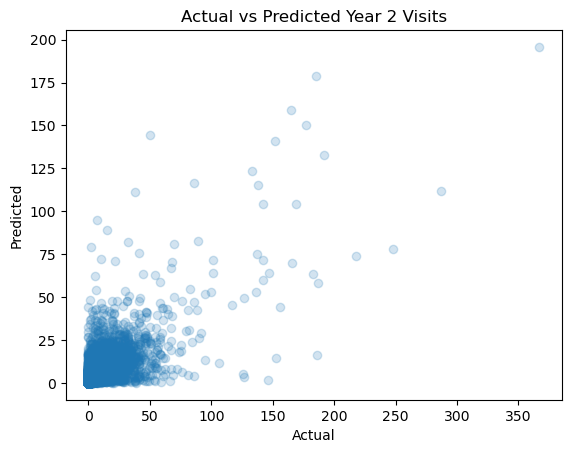

In [179]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_gb_tuned, alpha=0.2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Year 2 Visits")
plt.show()

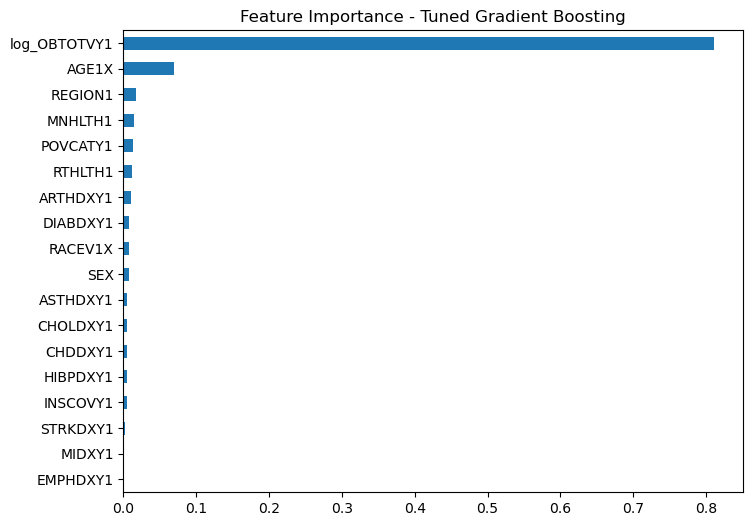

In [186]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(gb_tuned.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance - Tuned Gradient Boosting")
plt.show()

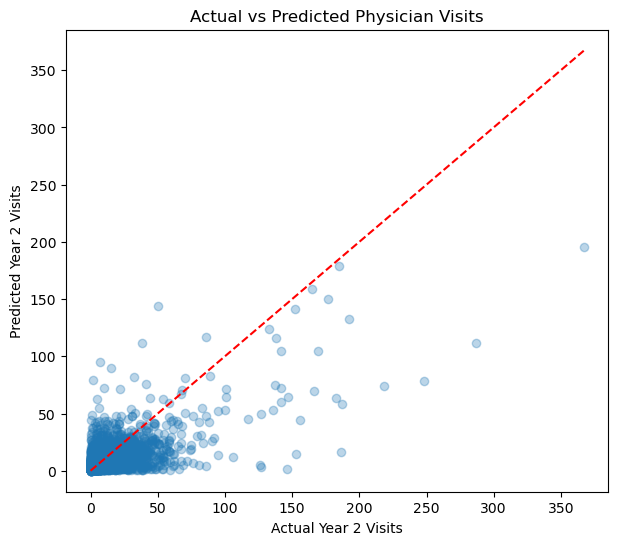

In [188]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(y_test, pred_gb_tuned, alpha=0.3)

plt.plot([0, max(y_test)], [0, max(y_test)], color="red", linestyle="--")

plt.xlabel("Actual Year 2 Visits")
plt.ylabel("Predicted Year 2 Visits")
plt.title("Actual vs Predicted Physician Visits")

plt.show()

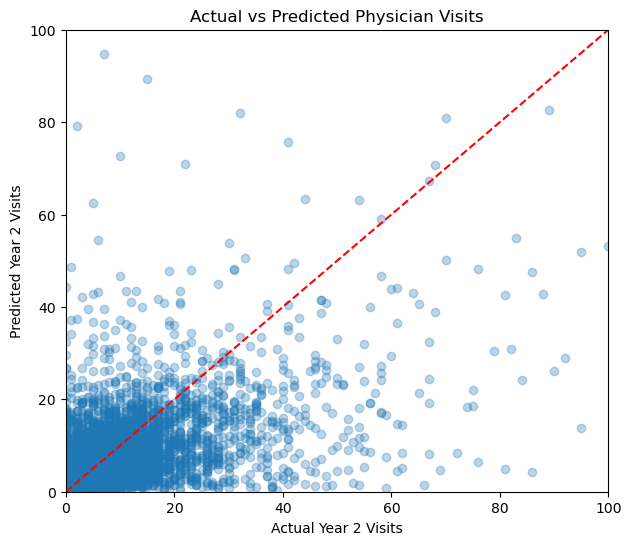

In [192]:

plt.figure(figsize=(7,6))

plt.scatter(y_test, pred_gb_tuned, alpha=0.3)

plt.plot([0, max(y_test)], [0, max(y_test)], color="red", linestyle="--")

plt.xlabel("Actual Year 2 Visits")
plt.ylabel("Predicted Year 2 Visits")
plt.title("Actual vs Predicted Physician Visits")

plt.xlim(0,100)
plt.ylim(0,100)

plt.show()